# Notebook 3 — Dataset físico-normativo Familia B + auditoría avanzada


- Filtro `Lx ≤ 100m` en `structural_case_ok` — edificios de barra chilenos reales
- Las dimensiones siguen dependiendo de `n_unid_lado`, `L_mod_m`, núcleo y corredor
- El generador funciona libre; el filtro descarta los casos con Lx excesivo
- `LX_MAX_M = 100.0` configurable en Celda 1

Este notebook genera un dataset estratificado de edificios sintéticos de Familia B para ser procesados por el Notebook OpenSees v3, que aplica el análisis modal espectral completo bajo NCh433.

## 🔧 Hito — Imports y configuración del dataset

Punto de arranque. Carga librerías, detecta **SciPy** (solver modal) y **h5py**, y fija todos los parámetros que gobiernan la generación:

- **Constantes normativas:** gravedad, límite de deriva NCh433 ($0.002$), amortiguamiento $\zeta = 5\%$ y mínimo de masa modal acumulada ($90\%$).
- **Dominio del dataset:** `N_CASES_TOTAL = 10000`, pisos de 6 a 18, los cuatro suelos $\{A,B,C,D\}$, zonas $\{1,2,3\}$ y semilla `SEED = 2026`.
- **Filtros de calidad estructural:** mínimo de muros, rango de relación $K_x/K_y$ ($0.35$–$3.00$), rango de densidad de muros ($0.020$–$0.090$) y largo máximo de edificio `LX_MAX_M = 100 m`.
- **Modulación constructiva:** `round_5cm`, que redondea dimensiones a múltiplos de 5 cm (encofrado estándar chileno), con una verificación incorporada.
- **Rutas de salida** (`dataset/final`, `intermediate`, `reports/figures`) y validación de que existan el JSON y el `core.py` del Notebook 1.

**Se obtiene:** el entorno configurado, los umbrales de filtrado, la función de modulación y las rutas — todo lo que define el dataset que se generará.

In [2]:
# ============================================================
# CELDA 1 — IMPORTS Y CONFIGURACIÓN
# Notebook 3 FINAL — Dominio único uniforme
# ============================================================

# ------------------------------------------------------------
# LIBRERÍAS BASE
# ------------------------------------------------------------
import os
import sys
import json
import pickle
import time
import traceback
import warnings
from pathlib import Path
from pprint import pprint
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# SCIPY — SOLVER MODAL
# ------------------------------------------------------------
try:
    from scipy.linalg import eigh
    SCIPY_AVAILABLE = True
except Exception as e:
    SCIPY_AVAILABLE = False
    print("WARNING: scipy.linalg.eigh no disponible:", e)

# ------------------------------------------------------------
# HDF5
# ------------------------------------------------------------
try:
    import h5py
    H5PY_AVAILABLE = True
except Exception:
    H5PY_AVAILABLE = False

# ------------------------------------------------------------
# VISUALIZACIÓN
# ------------------------------------------------------------
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.25
plt.rcParams["font.size"]      = 11

# ------------------------------------------------------------
# CONSTANTES FÍSICAS / NORMATIVAS
# ------------------------------------------------------------
G_ACCEL      = 9.81     # m/s²
DRIFT_LIMIT  = 0.002    # límite deriva NCh433
ZETA         = 0.05     # amortiguamiento 5%
MIN_MASS_ACC = 0.90     # mínimo 90% masa modal acumulada

# ------------------------------------------------------------
# RUTA PROYECTO
# ------------------------------------------------------------
PROJECT_ROOT = Path(r"C:\Users\rodri\Documents\PINN\b2_proyecto")

# ------------------------------------------------------------
# ARCHIVOS FAMILIA B
# ------------------------------------------------------------
FAMILIA_B_DIR  = PROJECT_ROOT / "notebooks" / "outputs" / "familia_B"
FAMILIA_B_JSON = FAMILIA_B_DIR / "familia_B_master.json"
FAMILIA_B_CORE = FAMILIA_B_DIR / "familia_B_core.py"

if str(FAMILIA_B_DIR) not in sys.path:
    sys.path.insert(0, str(FAMILIA_B_DIR))

# ------------------------------------------------------------
# CARPETAS OUTPUT
# ------------------------------------------------------------
OUT_DATA_DIR         = PROJECT_ROOT / "dataset" / "final"
OUT_INTERMEDIATE_DIR = PROJECT_ROOT / "dataset" / "intermediate"
OUT_REPORT_DIR       = PROJECT_ROOT / "dataset" / "reports"
OUT_FIG_DIR          = OUT_REPORT_DIR / "figures"

for d in [OUT_DATA_DIR, OUT_INTERMEDIATE_DIR, OUT_REPORT_DIR, OUT_FIG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# CONFIGURACIÓN DATASET FINAL — DOMINIO ÚNICO UNIFORME
# ------------------------------------------------------------
SEED          = 2026
rng           = np.random.default_rng(SEED)
N_CASES_TOTAL = 10000

# Sin distinción realista/extremo — un solo dominio coherente
ALL_FLOORS = np.arange(6, 19)        # 6 a 18 pisos
ALL_SOILS  = ["A", "B", "C", "D"]   # todos los suelos NCh433

# ------------------------------------------------------------
# FILTROS DE CALIDAD ESTRUCTURAL
# ------------------------------------------------------------
MIN_WALLS        = 10
K_RATIO_MIN      = 0.35
K_RATIO_MAX      = 3.00
WALL_DENSITY_MIN = 0.020
WALL_DENSITY_MAX = 0.090

# ------------------------------------------------------------
# LIMITE DE LARGO MAXIMO — Edificios de barra chilenos reales
# Lx depende de n_unid_lado * L_mod * mods_por_depto + extras
# Con n_unid_lado hasta 9 → Lx puede llegar a 158m (irreal)
# Con Lx_max=100m se permiten edificios grandes pero realistas
# ------------------------------------------------------------
LX_MAX_M = 100.0    # metros — limite fisico de largo del edificio

# ------------------------------------------------------------
# ANÁLISIS MODAL
# ------------------------------------------------------------
N_MODOS_MAX = 12

# ------------------------------------------------------------
# MODULACIÓN CONSTRUCTIVA — redondeo a 5cm
# ------------------------------------------------------------
def round_5cm(value):
    """
    Redondea al múltiplo de 5cm más cercano.
    Modulación constructiva estándar en Chile para encofrados.
    Ejemplo: 3.4977 → 3.50  |  7.4548 → 7.45  |  1.7017 → 1.70
    """
    return round(round(value / 0.05) * 0.05, 4)

# ------------------------------------------------------------
# CHEQUEO DE RUTAS Y RESUMEN
# ------------------------------------------------------------
print("="*70)
print("CELDA 1 — CONFIGURACIÓN — DOMINIO ÚNICO UNIFORME")
print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"Existe JSON    : {FAMILIA_B_JSON.exists()}")
print(f"Existe CORE    : {FAMILIA_B_CORE.exists()}")
print(f"SCIPY          : {SCIPY_AVAILABLE}")
print(f"H5PY           : {H5PY_AVAILABLE}")
print("-"*70)
print(f"N casos        : {N_CASES_TOTAL}")
print(f"N_pisos rango  : {ALL_FLOORS[0]} a {ALL_FLOORS[-1]}")
print(f"Suelos         : {ALL_SOILS}")
print(f"Zonas          : [1, 2, 3]")
print(f"Seed           : {SEED}")
print("-"*70)
print(f"Kx/Ky          : {K_RATIO_MIN:.2f} a {K_RATIO_MAX:.2f}")
print(f"Densidad muros : {WALL_DENSITY_MIN:.3f} a {WALL_DENSITY_MAX:.3f}")
print(f"Muros mínimos  : {MIN_WALLS}")
print(f"Lx máximo      : {LX_MAX_M:.0f} m  ← filtro largo edificio")
print(f"Modulación     : 5cm (round_5cm)")
print("="*70)

# Verificación rápida de round_5cm
_test = [3.4977, 7.4548, 1.7017, 5.9931, 4.5023, 2.7498]
_expected = [3.50, 7.45, 1.70, 6.00, 4.50, 2.75]
print("Verificación round_5cm:")
for v, e in zip(_test, _expected):
    r = round_5cm(v)
    ok = "✅" if r == e else "⚠️"
    print(f"  {v} → {r}  (esperado {e}) {ok}")

if not FAMILIA_B_JSON.exists():
    raise FileNotFoundError(f"No existe: {FAMILIA_B_JSON}")
if not FAMILIA_B_CORE.exists():
    raise FileNotFoundError(f"No existe: {FAMILIA_B_CORE}")
if not SCIPY_AVAILABLE:
    raise RuntimeError("scipy.linalg.eigh no disponible.")

CELDA 1 — CONFIGURACIÓN — DOMINIO ÚNICO UNIFORME
PROJECT_ROOT   : C:\Users\rodri\Documents\PINN\b2_proyecto
Existe JSON    : True
Existe CORE    : True
SCIPY          : True
H5PY           : True
----------------------------------------------------------------------
N casos        : 10000
N_pisos rango  : 6 a 18
Suelos         : ['A', 'B', 'C', 'D']
Zonas          : [1, 2, 3]
Seed           : 2026
----------------------------------------------------------------------
Kx/Ky          : 0.35 a 3.00
Densidad muros : 0.020 a 0.090
Muros mínimos  : 10
Lx máximo      : 100 m  ← filtro largo edificio
Modulación     : 5cm (round_5cm)
Verificación round_5cm:
  3.4977 → 3.5  (esperado 3.5) ✅
  7.4548 → 7.45  (esperado 7.45) ✅
  1.7017 → 1.7  (esperado 1.7) ✅
  5.9931 → 6.0  (esperado 6.0) ✅
  4.5023 → 4.5  (esperado 4.5) ✅
  2.7498 → 2.75  (esperado 2.75) ✅


## Fórmulas base

Problema modal:

$$
K\phi_r=\omega_r^2M\phi_r
$$

Período:

$$
T_r=\frac{2\pi}{\omega_r}
$$

## 📥 Hito — Carga oficial de la Familia B (desde Notebook 1)

Importa la tipología oficial: agrega la carpeta del Notebook 1 al `sys.path`, hace `from familia_B_core import *` (trae `build_params_B`, `build_family_B_geometry`, etc.) y carga `FAMILIA_B_CFG` desde el JSON maestro. Aplica **asserts de consistencia** con la versión final (rango de pisos $[6,18]$ y suelos $\{A,B,C,D\}$).

**Se obtiene:** las funciones generadoras y la configuración validada, garantizando que el dataset se construye sobre la Familia B oficial.

In [3]:
# ============================================================
# CELDA 2 — CARGA OFICIAL DE LA FAMILIA B
# ============================================================
if not FAMILIA_B_JSON.exists():
    raise FileNotFoundError(f"No existe: {FAMILIA_B_JSON}")

if not FAMILIA_B_CORE.exists():
    raise FileNotFoundError(f"No existe: {FAMILIA_B_CORE}")

sys.path.insert(0, str(FAMILIA_B_DIR.resolve()))

from familia_B_core import *

with open(FAMILIA_B_JSON, "r", encoding="utf-8") as f:
    FAMILIA_B_CFG = json.load(f)

print("="*90)
print("FAMILIA B OFICIAL CARGADA")
print("="*90)
print("Nombre:", FAMILIA_B_CFG["meta"]["family_name"])
print("Rango N:", FAMILIA_B_CFG["variable_ranges"]["N_pisos"])
print("Suelos:", FAMILIA_B_CFG["variable_ranges"]["suelo"])

assert FAMILIA_B_CFG["variable_ranges"]["N_pisos"]["min"] == 6
assert FAMILIA_B_CFG["variable_ranges"]["N_pisos"]["max"] == 18
assert set(FAMILIA_B_CFG["variable_ranges"]["suelo"]["values"]) == {"A","B","C","D"}

FAMILIA B OFICIAL CARGADA
Nombre: Familia B
Rango N: {'type': 'int', 'min': 6, 'max': 18}
Suelos: {'type': 'choice', 'values': ['A', 'B', 'C', 'D']}


## 🧱 Hito — Funciones de geometría, masa y rigidez

Define la maquinaria estructural que se aplicará a cada caso:

- **`geometry_to_wall_df`** — convierte los muros del diccionario `geom` en un DataFrame con grupo, orientación, posición, dimensiones, centroide y área en planta.
- **`audit_wall_geometry`** — chequeos geométricos (existencia de grupos, muros dentro de la planta, B2 de altura completa, B3 verticales, mínimo de B4) y densidad de muros, con veredicto `geometry_pass`.
- **`compute_floor_masses`** — peso/masa sísmica por piso con tratamiento aparte de la cubierta ($\psi = 0$).
- **Rigidez de muros con discretización de B4** (`split_x_wall_with_openings`, `expand_B4_walls_with_openings`, `wall_directional_stiffness`, `compute_story_stiffness_from_walls`) — rigidez direccional fisurada ($\eta = 0.35$, flexión + corte) y descomposición de los muros de pasillo descontando aberturas, para evitar inercias infladas por $L^3$.

**Se obtiene:** el conjunto de funciones que transforman un edificio en su tabla de muros, su masa por piso y sus rigideces de entrepiso $K_x$, $K_y$, $K_\theta$.

In [4]:
# ============================================================
# CELDA 3 — FUNCIONES: GEOMETRÍA, MASA, RIGIDEZ
# ============================================================
def geometry_to_wall_df(geom, params):
    rows = []
    for w in geom["walls"]:
        x, y, ww, hh = float(w["x"]), float(w["y"]), float(w["w"]), float(w["h"])
        rows.append({
            "label": w.get("label", ""),
            "group": w.get("group", ""),
            "role": w.get("role", ""),
            "orientation": w.get("orientation", ""),
            "x": x, "y": y, "w": ww, "h": hh,
            "cx": x + ww/2,
            "cy": y + hh/2,
            "area_plan_m2": ww * hh,
        })
    return pd.DataFrame(rows)


def audit_wall_geometry(params, geom, wall_df, tol=1e-9):
    Lx, Ly = params["Lx_m"], params["Ly_m"]
    checks = {}

    checks["n_walls_total"] = len(wall_df)
    checks["has_B1"] = bool((wall_df["group"] == "B1").any())
    checks["has_B2"] = bool((wall_df["group"] == "B2").any())
    checks["has_B3"] = bool((wall_df["group"] == "B3").any())
    checks["has_B4"] = bool((wall_df["group"] == "B4").any())

    checks["all_walls_positive_size"] = bool(((wall_df["w"] > tol) & (wall_df["h"] > tol)).all())

    inside_x = (wall_df["x"] >= -tol) & (wall_df["x"] + wall_df["w"] <= Lx + tol)
    inside_y = (wall_df["y"] >= -tol) & (wall_df["y"] + wall_df["h"] <= Ly + tol)
    checks["all_walls_inside_plan"] = bool((inside_x & inside_y).all())

    b2 = wall_df[wall_df["group"] == "B2"]
    checks["B2_full_height_ok"] = bool(len(b2) == 0 or (np.isclose(b2["h"], Ly, atol=1e-6)).all())

    b3 = wall_df[wall_df["group"] == "B3"]
    checks["B3_vertical_ok"] = bool(len(b3) == 0 or (b3["h"] > b3["w"]).all())

    b4 = wall_df[wall_df["group"] == "B4"]
    checks["B4_count_ok"] = bool(len(b4) >= 3)

    checks["wall_density_plan"] = float(wall_df["area_plan_m2"].sum() / params["A_geom_m2"])

    checks["geometry_pass"] = bool(
        checks["has_B1"] and
        checks["has_B4"] and
        checks["all_walls_positive_size"] and
        checks["all_walls_inside_plan"] and
        checks["B2_full_height_ok"] and
        checks["B3_vertical_ok"] and
        checks["B4_count_ok"]
    )
    return checks


def compute_floor_masses(params):
    A = params["A_geom_m2"]
    gk = params["gk_kN_m2"]
    qk = FAMILIA_B_CFG["fixed"].get("qk_default_kN_m2", 2.0)
    psi_floor = FAMILIA_B_CFG["fixed"].get("psi_default", 0.25)
    psi_roof = 0.0

    W_floor_kN = A * (gk + psi_floor * qk)
    W_roof_kN  = A * (gk + psi_roof * qk)

    m_floor_kg = W_floor_kN * 1000.0 / G_ACCEL
    m_roof_kg  = W_roof_kN  * 1000.0 / G_ACCEL

    N = int(params["N_pisos"])
    masses = np.full(N, m_floor_kg, dtype=float)
    masses[-1] = m_roof_kg

    M_total_kg = masses.sum()
    W_total_kN = (N - 1) * W_floor_kN + W_roof_kN

    return masses, M_total_kg, W_floor_kN, W_roof_kN, W_total_kN


NU_CONC = 0.20
ETA_CRACKED_WALL = 0.35
KAPPA_SHEAR = 1.20
OPENING_DEPT_M = 0.90
OPENING_TECH_M = 0.90
OPENING_HALL_M = 1.40


def split_x_wall_with_openings(wall, p):
    x0 = float(wall["x"])
    x1 = float(wall["x"] + wall["w"])
    y  = float(wall["y"])
    t  = float(wall["h"])

    L_mod = float(p["L_mod_m"])
    mods_por_depto = int(p["mods_por_depto"])
    dept_w = mods_por_depto * L_mod

    x_nuc_0 = p["n_mod_izq"] * L_mod
    x_nuc_1 = x_nuc_0 + p["L_nucleo_m"]

    segments = []
    current = x0
    idx = 1

    while current < x1 - 1e-9:
        bay_start = current
        bay_end = min(current + dept_w, x1)
        bay_len = bay_end - bay_start

        if bay_len <= 0.30:
            break

        bay_mid = 0.5 * (bay_start + bay_end)

        if (bay_start <= x_nuc_0 <= bay_end) or (bay_start <= x_nuc_1 <= bay_end) or (x_nuc_0 <= bay_mid <= x_nuc_1):
            opening = OPENING_HALL_M
            use_type = "hall"
        elif abs(bay_end - x_nuc_0) < 1e-6 or abs(bay_start - x_nuc_1) < 1e-6:
            opening = OPENING_TECH_M
            use_type = "tecnico"
        else:
            opening = OPENING_DEPT_M
            use_type = "depto"

        opening = min(opening, 0.60 * bay_len)
        solid_total = bay_len - opening

        if solid_total > 0.40:
            solid_each = 0.5 * solid_total
            for sx, sw, side in [(bay_start, solid_each, "L"), (bay_end - solid_each, solid_each, "R")]:
                if sw > 0.20:
                    new_wall = dict(wall)
                    new_wall["x"] = sx
                    new_wall["y"] = y
                    new_wall["w"] = sw
                    new_wall["h"] = t
                    new_wall["label"] = f'{wall["label"]}-{idx}-{use_type}-{side}'
                    new_wall["original_label"] = wall["label"]
                    new_wall["opening_type"] = use_type
                    segments.append(new_wall)
            idx += 1

        current = bay_end

    return segments


def expand_B4_walls_with_openings(wall_df, p):
    rows = []
    for _, row in wall_df.iterrows():
        w = row.to_dict()
        if w.get("group") == "B4" and w["w"] >= w["h"]:
            rows.extend(split_x_wall_with_openings(w, p))
        else:
            rows.append(w)
    return pd.DataFrame(rows)


def wall_directional_stiffness(wall, p):
    E = float(p["E_MPa"]) * 1e6
    Eeff = ETA_CRACKED_WALL * E
    G = Eeff / (2.0 * (1.0 + NU_CONC))
    h_story = float(p["h_story_m"])

    w = float(wall["w"])
    h = float(wall["h"])

    if w >= h:
        orientation = "X"
        L = w
        t = h
    else:
        orientation = "Y"
        L = h
        t = w

    L = max(L, 0.20)
    t = max(t, 0.10)

    I_fuerte = t * L**3 / 12.0
    I_debil  = L * t**3 / 12.0
    A_shear = t * L

    def k_wall(I):
        flex = h_story**3 / (12.0 * Eeff * I)
        shear = KAPPA_SHEAR * h_story / (G * A_shear)
        return 1.0 / (flex + shear)

    k_fuerte = k_wall(I_fuerte)
    k_debil  = k_wall(I_debil)

    if orientation == "X":
        kx, ky = k_debil, k_fuerte
    else:
        kx, ky = k_fuerte, k_debil

    cx = float(wall["x"] + wall["w"] / 2.0)
    cy = float(wall["y"] + wall["h"] / 2.0)
    x_cm = p["Lx_m"] / 2.0
    y_cm = p["Ly_m"] / 2.0

    ktheta = kx * (cy - y_cm)**2 + ky * (cx - x_cm)**2

    return {
        "label": wall.get("label", ""),
        "group": wall.get("group", ""),
        "orientation_calc": orientation,
        "kx_i": kx,
        "ky_i": ky,
        "ktheta_i": ktheta,
        "cx": cx,
        "cy": cy,
    }


def compute_story_stiffness_from_walls(params, wall_df):
    wall_df_struct = expand_B4_walls_with_openings(wall_df, params)
    stiff_df = pd.DataFrame([wall_directional_stiffness(w, params) for _, w in wall_df_struct.iterrows()])
    return {
        "wall_df_struct": wall_df_struct,
        "stiff_df": stiff_df,
        "Kx_story": float(stiff_df["kx_i"].sum()),
        "Ky_story": float(stiff_df["ky_i"].sum()),
        "Ktheta_story": float(stiff_df["ktheta_i"].sum()),
    }

## 🏗️ Hito — Ensamblaje de matrices y análisis modal

Define el modelo dinámico reducido tipo **edificio de corte con 3 GDL por piso** ($U_x, U_y, \theta_z$):

- **`assemble_shear_building_matrices`** — arma $M$ (masas traslacionales más inercia rotacional $m\,r^2$) y $K$ mediante resortes de entrepiso (piso 1 a base fija, piso $i$ acoplado al $i-1$).
- **`solve_modal_matrices`** — resuelve $K\phi = \omega^2 M\phi$ con `eigh`, descarta modos espurios, obtiene períodos $T$ y normaliza $\Phi$ a masa unitaria.
- **`modal_participation_effective_mass`** — factores de participación y masa efectiva acumulada en X e Y.
- **`first_mode_reaching_mass`** — número de modos para alcanzar el 90% de masa.

**Se obtiene:** las funciones que, dadas masa y rigidez, entregan períodos, formas modales y participación de masa de un edificio.

In [5]:
# ============================================================
# CELDA 4 — MATRICES Y ANÁLISIS MODAL
# ============================================================
def assemble_shear_building_matrices(params, floor_masses, stiff):
    """
    Ensambla M y K para shear building con 3 GDL por piso:
    [Ux_i, Uy_i, Rz_i].

    La rigidez se arma con resortes de entrepiso:
    - Piso 1 conectado a base fija.
    - Piso i conectado al piso i-1.
    - No se agrega rigidez absoluta extra en cada piso.
    """
    N = int(params["N_pisos"])
    D = 3 * N

    M = np.zeros((D, D), dtype=float)
    K = np.zeros((D, D), dtype=float)

    Lx = float(params["Lx_m"])
    Ly = float(params["Ly_m"])
    r2 = (Lx**2 + Ly**2) / 12.0

    for i in range(N):
        m = float(floor_masses[i])
        M[3*i,   3*i]   = m
        M[3*i+1, 3*i+1] = m
        M[3*i+2, 3*i+2] = m * r2

    kx = float(stiff["Kx_story"])
    ky = float(stiff["Ky_story"])
    kt = float(stiff["Ktheta_story"])

    def add_spring_to_ground(dof, k):
        K[dof, dof] += k

    def add_spring_between(dof_i, dof_j, k):
        K[dof_i, dof_i] += k
        K[dof_j, dof_j] += k
        K[dof_i, dof_j] -= k
        K[dof_j, dof_i] -= k

    for i in range(N):
        dof_x_i = 3*i
        dof_y_i = 3*i + 1
        dof_t_i = 3*i + 2

        if i == 0:
            add_spring_to_ground(dof_x_i, kx)
            add_spring_to_ground(dof_y_i, ky)
            add_spring_to_ground(dof_t_i, kt)
        else:
            dof_x_j = 3*(i-1)
            dof_y_j = 3*(i-1) + 1
            dof_t_j = 3*(i-1) + 2

            add_spring_between(dof_x_i, dof_x_j, kx)
            add_spring_between(dof_y_i, dof_y_j, ky)
            add_spring_between(dof_t_i, dof_t_j, kt)

    return M, K

def solve_modal_matrices(M, K, n_modes=None):
    if not SCIPY_AVAILABLE:
        raise RuntimeError("scipy.linalg.eigh no está disponible.")

    D = M.shape[0]
    n_modes = D if n_modes is None else min(n_modes, D)

    vals, vecs = eigh(K, M)
    idx = np.argsort(vals)
    vals = np.real(vals[idx])
    vecs = np.real(vecs[:, idx])

    pos = vals > 1e-10
    vals = vals[pos][:n_modes]
    vecs = vecs[:, pos][:, :n_modes]

    omegas = np.sqrt(vals)
    periods = 2*np.pi/omegas

    Phi = vecs.copy()
    for r in range(Phi.shape[1]):
        mr = Phi[:, r].T @ M @ Phi[:, r]
        Phi[:, r] /= np.sqrt(abs(mr))

    return {"lambdas": vals, "omegas": omegas, "T": periods, "Phi": Phi}


def modal_participation_effective_mass(M, Phi, params):
    N = int(params["N_pisos"])
    D = 3*N

    rx = np.zeros(D)
    ry = np.zeros(D)
    for i in range(N):
        rx[3*i] = 1.0
        ry[3*i+1] = 1.0

    Mtot_x = rx.T @ M @ rx
    Mtot_y = ry.T @ M @ ry

    Kmod = Phi.shape[1]
    gamma_x = np.zeros(Kmod)
    gamma_y = np.zeros(Kmod)
    meff_x = np.zeros(Kmod)
    meff_y = np.zeros(Kmod)

    for r in range(Kmod):
        phi = Phi[:, r]
        den = phi.T @ M @ phi
        gamma_x[r] = (phi.T @ M @ rx) / den
        gamma_y[r] = (phi.T @ M @ ry) / den
        meff_x[r] = ((phi.T @ M @ rx)**2) / (den * Mtot_x)
        meff_y[r] = ((phi.T @ M @ ry)**2) / (den * Mtot_y)

    return {
        "Gamma_x": gamma_x,
        "Gamma_y": gamma_y,
        "mass_part_x": meff_x,
        "mass_part_y": meff_y,
        "mass_acc_x": np.cumsum(meff_x),
        "mass_acc_y": np.cumsum(meff_y),
    }


def first_mode_reaching_mass(acc, target=0.90):
    idx = np.where(acc >= target)[0]
    return np.nan if len(idx) == 0 else int(idx[0] + 1)


def audit_modal_case(params, modal, part):
    T = modal["T"]
    acc_x = part["mass_acc_x"]
    acc_y = part["mass_acc_y"]

    n90_x = first_mode_reaching_mass(acc_x, MIN_MASS_ACC)
    n90_y = first_mode_reaching_mass(acc_y, MIN_MASS_ACC)

    T1 = float(T[0]) if len(T) > 0 else np.nan

    return {
        "T_positive": bool(np.all(T > 0)),
        "T1_s": T1,
        "n90_x": n90_x,
        "n90_y": n90_y,
        "acc_x_last": float(acc_x[-1]) if len(acc_x) else np.nan,
        "acc_y_last": float(acc_y[-1]) if len(acc_y) else np.nan,
        "mass90_x_ok": bool(np.isfinite(n90_x)),
        "mass90_y_ok": bool(np.isfinite(n90_y)),
        "modal_case_pass": bool(np.isfinite(T1) and 0.05 <= T1 <= 3.0 and np.isfinite(n90_x) and np.isfinite(n90_y)),
    }

## 🌊 Hito — Espectro de diseño NCh433/DS61 y combinación CQC

Implementa el **espectro normativo** y la combinación modal, núcleo del cálculo de demanda sísmica:

- Tablas de aceleración efectiva por zona ($A_0$) y parámetros de suelo ($S, T_0, T', n, p$) según NCh433 Mod.2012 + DS61.
- **`Rstar_nch433_excel`** y **`alpha_nch433_excel`** — factor de reducción $R^*$ y factor de amplificación $\alpha(T)$.
- **`Sa_design_excel`** — espectro de diseño con sus cotas mínima y máxima; **`Sd_from_Sa`** convierte a desplazamiento espectral.
- **`cqc_rho` / `cqc_combine_modal`** — coeficientes de correlación y **combinación cuadrática completa (CQC)** de respuestas modales.
- **`compute_modal_response_spectral`** — respuesta espectral por modo combinada por CQC.

**Se obtiene:** las funciones que entregan la pseudo-aceleración de diseño, los desplazamientos espectrales y la respuesta combinada por CQC para cualquier edificio.

In [6]:
# ============================================================
# CELDA 5 — ESPECTRO NCh433 Mod.Of2012 + DS61
# ============================================================

# ------------------------------------------------------------
# TABLAS BASE
# ------------------------------------------------------------
A0_BY_ZONE_G = {
    1: 0.20,
    2: 0.30,
    3: 0.40,
}

SOIL_PARAMS = {
    "A": dict(S=0.90, T0=0.15, Tp=0.20, n=1.00, p=2.00),
    "B": dict(S=1.00, T0=0.30, Tp=0.35, n=1.33, p=1.50),
    "C": dict(S=1.05, T0=0.40, Tp=0.45, n=1.40, p=1.60),
    "D": dict(S=1.20, T0=0.75, Tp=0.85, n=1.80, p=1.00),
}

I_FIXED  = 1.00
R_FIXED  = 7.00
RO_FIXED = 11.0
ZETA     = 0.05


# ------------------------------------------------------------
# R*
# ------------------------------------------------------------
def Rstar_nch433_excel(T_star, T0, Ro=RO_FIXED):
    T_star = float(max(T_star, 1e-6))
    den = 0.10 * T0 + T_star / (Ro - 1.0)
    return 1.0 + T_star / den


# ------------------------------------------------------------
# alpha(T)
# alpha=(1+4.5*(T/Tp)^n)/(1+(T/Tp)^3)
# ------------------------------------------------------------
def alpha_nch433_excel(T, Tp, n):
    T = np.asarray(T, dtype=float)
    x = np.maximum(T, 0.0) / Tp
    return (1.0 + 4.5 * (x ** n)) / (1.0 + (x ** 3))


# ------------------------------------------------------------
# Espectro completo 
# ------------------------------------------------------------
def Sa_design_excel(T, zone, soil, I=I_FIXED, Ro=RO_FIXED, T_star=0.30):
    pars = SOIL_PARAMS[str(soil).upper()]

    A0 = A0_BY_ZONE_G[int(zone)]
    S  = pars["S"]
    T0 = pars["T0"]
    Tp = pars["Tp"]
    n  = pars["n"]

    Rstar = Rstar_nch433_excel(T_star=T_star, T0=T0, Ro=Ro)

    alpha = alpha_nch433_excel(T, Tp=Tp, n=n)

    # Espectro elástico
    Sa_elastic_g = S * A0 * alpha * I

    # Límites
    Sa_min_g = S * A0 * I / 6.0
    Sa_max_g = 0.35 * S * A0

    # Diseño final
    Sa_design_g = np.maximum(
        Sa_min_g,
        np.minimum(Sa_max_g, Sa_elastic_g / Rstar)
    )

    return {
        "Sa_elastic_g": Sa_elastic_g,
        "Sa_design_g": Sa_design_g,
        "Sa_min_g": np.full_like(np.asarray(T, dtype=float), Sa_min_g),
        "Sa_max_g": np.full_like(np.asarray(T, dtype=float), Sa_max_g),
        "alpha": alpha,
        "Rstar": Rstar,
        "A0": A0,
        "S": S,
        "T0": T0,
        "Tp": Tp,
        "n": n,
    }


def Sd_from_Sa(Sa_m_s2, T):
    omega = 2*np.pi / np.maximum(np.asarray(T, dtype=float), 1e-12)
    return Sa_m_s2 / (omega**2)


# ------------------------------------------------------------
# CQC
# ------------------------------------------------------------
def cqc_rho(omega_i, omega_j, zeta=0.05):
    if omega_i <= 0 or omega_j <= 0:
        return 0.0

    beta = omega_j / omega_i

    num = 8*zeta**2*(1+beta)*beta**1.5
    den = (1-beta**2)**2 + 4*zeta**2*beta*(1+beta)**2

    return num/den if den > 0 else 0.0


def cqc_combine_modal(values, omegas, zeta=0.05):
    values = np.asarray(values, dtype=float)
    omegas = np.asarray(omegas, dtype=float)

    s = 0.0
    K = len(values)

    for i in range(K):
        for j in range(K):
            s += cqc_rho(omegas[i], omegas[j], zeta) * values[i] * values[j]

    return float(np.sqrt(max(s, 0.0)))


# ------------------------------------------------------------
# RESPUESTA MODAL ESPECTRAL
# ------------------------------------------------------------
def compute_modal_response_spectral(params, modal, part, floor_masses):
    T = np.asarray(modal["T"], dtype=float)
    omegas = np.asarray(modal["omegas"], dtype=float)
    Phi = modal["Phi"]

    N = int(params["N_pisos"])
    Kmod = len(T)

    T_star = float(T[0])

    spec = Sa_design_excel(
        T,
        zone=params["zona"],
        soil=params["suelo"],
        I=I_FIXED,
        Ro=RO_FIXED,
        T_star=T_star
    )

    Sa_g = spec["Sa_design_g"]
    Sa = Sa_g * G_ACCEL
    Sd = Sd_from_Sa(Sa, T)

    Ux = np.zeros(N)
    Uy = np.zeros(N)

    for i in range(N):
        vals_x = []
        vals_y = []

        for r in range(Kmod):
            vals_x.append(Phi[3*i, r]   * part["Gamma_x"][r] * Sd[r])
            vals_y.append(Phi[3*i+1, r] * part["Gamma_y"][r] * Sd[r])

        Ux[i] = cqc_combine_modal(vals_x, omegas, ZETA)
        Uy[i] = cqc_combine_modal(vals_y, omegas, ZETA)

    h = float(params["h_story_m"])

    drift_x = np.zeros(N)
    drift_y = np.zeros(N)

    drift_x[0] = abs(Ux[0]) / h
    drift_y[0] = abs(Uy[0]) / h

    for i in range(1, N):
        drift_x[i] = abs(Ux[i] - Ux[i-1]) / h
        drift_y[i] = abs(Uy[i] - Uy[i-1]) / h

    M_total = float(np.sum(floor_masses))

    Vb_x_modes = part["mass_part_x"] * M_total * Sa
    Vb_y_modes = part["mass_part_y"] * M_total * Sa

    Vb_x_N = cqc_combine_modal(Vb_x_modes, omegas, ZETA)
    Vb_y_N = cqc_combine_modal(Vb_y_modes, omegas, ZETA)

    return {
        "Sa_g": Sa_g,
        "Sa_m_s2": Sa,
        "Sd_m": Sd,
        "alpha": spec["alpha"],
        "Rstar": spec["Rstar"],
        "Sa_elastic_g": spec["Sa_elastic_g"],
        "Sa_min_g": spec["Sa_min_g"],
        "Sa_max_g": spec["Sa_max_g"],

        "Ux_m": Ux,
        "Uy_m": Uy,

        "u_roof_x_m": float(Ux[-1]),
        "u_roof_y_m": float(Uy[-1]),

        "drift_x": drift_x,
        "drift_y": drift_y,

        "drift_max_x": float(np.max(drift_x)),
        "drift_max_y": float(np.max(drift_y)),

        "Vb_x_N": float(Vb_x_N),
        "Vb_y_N": float(Vb_y_N),
        "Vb_x_kN": float(Vb_x_N / 1000.0),
        "Vb_y_kN": float(Vb_y_N / 1000.0),
    }


# ------------------------------------------------------------
# CHEQUEO NORMATIVO PRELIMINAR
# ------------------------------------------------------------
def check_normative_simplified(params, response, W_total_kN):
    A0 = A0_BY_ZONE_G[int(params["zona"])]

    Vb_min_kN = 0.075 * A0 * I_FIXED * W_total_kN / R_FIXED

    drift_ok_x = response["drift_max_x"] <= DRIFT_LIMIT
    drift_ok_y = response["drift_max_y"] <= DRIFT_LIMIT

    vb_ok_x = response["Vb_x_kN"] >= Vb_min_kN
    vb_ok_y = response["Vb_y_kN"] >= Vb_min_kN

    cumple = bool(drift_ok_x and drift_ok_y and vb_ok_x and vb_ok_y)

    fails = []
    if not drift_ok_x: fails.append("drift_x")
    if not drift_ok_y: fails.append("drift_y")
    if not vb_ok_x: fails.append("Vb_min_x")
    if not vb_ok_y: fails.append("Vb_min_y")

    return {
        "Vb_min_kN": float(Vb_min_kN),
        "Vb_x_kN": response["Vb_x_kN"],
        "Vb_y_kN": response["Vb_y_kN"],
        "cumple": cumple,
        "motivo_falla": "cumple" if cumple else "+".join(fails),
    }

## 🔗 Hito — Análisis completo de un caso y fila del dataset

`build_ordered_row` y la función de análisis integran **todo el flujo por edificio** (geometría → muros → masa → rigidez → matrices → modal → respuesta espectral → chequeos normativos) y lo serializan en una **fila ordenada del dataset**: identificación, inputs de generación, parámetros geométricos derivados, material y cargas, masa, rigidez, resultados modales, respuesta sísmica y banderas de cumplimiento.

**Se obtiene:** el registro estructurado (una fila por caso) que constituye la unidad de datos del dataset final, con todos los campos que consumirá la PINN.

CASO PILOTO NOTEBOOK 3
{'A_geom_m2': 1269.2,
 'A_hall_m2': 45.0,
 'A_tecnica_m2': 105.0,
 'A_util_m2': 945.0,
 'B_nucleo_frac_Ly': 0.2694610778443114,
 'B_nucleo_m': 4.5,
 'E_MPa': np.float64(25742.960202742808),
 'H_total_m': 27.0,
 'Ktheta_story': 12418358113812.057,
 'Kx_Ky_ratio': 1.8338196757807077,
 'Kx_story': 42714536994.80355,
 'Ky_story': 23292659337.739296,
 'L_mod_m': 3.5,
 'L_nucleo_m': 6.0,
 'Lx_m': 76.0,
 'Ly_m': 16.7,
 'M_total_kg': np.float64(9638674.821610602),
 'N_pisos': 10,
 'T1_s': np.float64(0.26962080914550274),
 'T2_s': np.float64(0.26229702283010126),
 'T3_s': np.float64(0.19910175750381298),
 'Vb_x_kN': 11837.620591548455,
 'Vb_y_kN': 11850.469216001944,
 'W_floor_kN': 9519.0,
 'W_roof_kN': 8884.4,
 'W_total_kN': 94555.4,
 'acc_x_last': 0.970394512444592,
 'acc_y_last': 0.9920910805803406,
 'activar_B2': 1,
 'activar_B3': 1,
 'ancho_corredor_m': 1.7,
 'aspect_ratio_Lx_Ly': 4.550898203592815,
 'case_id': 'piloto',
 'cumple': True,
 'drift_max_x': 0.00010264196

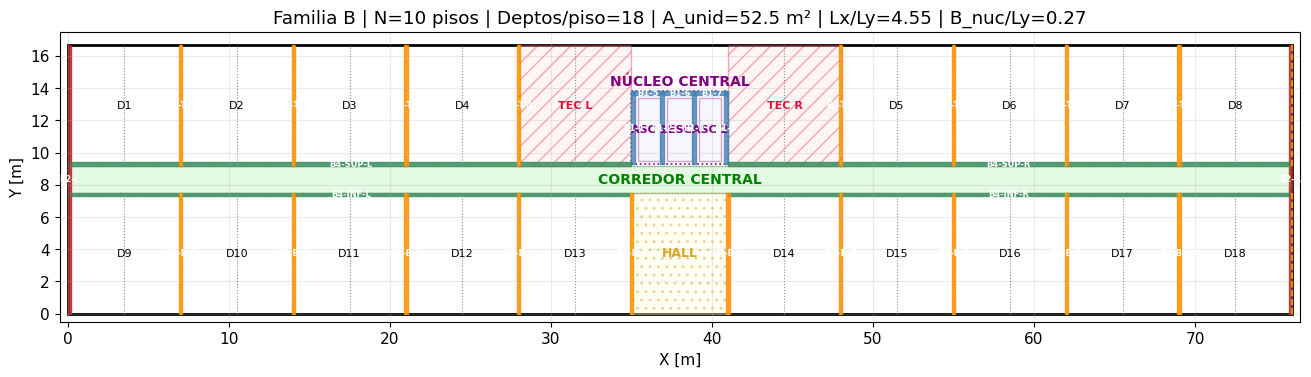

In [7]:
# ============================================================
# CELDA 6 — ANÁLISIS COMPLETO DE UN CASO
# ============================================================
def build_ordered_row(case_id, params, geom_checks, floor_masses, M_total, W_floor_kN, W_roof_kN, W_total_kN,
                      wall_df, stiff, modal, part, modal_checks, response, norm, sample_seed=None,
                      rigidity_class=None):
    """
    Fila ordenada del dataset:
    1) identificación / estrategia de muestreo
    2) inputs variables
    3) parámetros derivados geométricos
    4) masa, rigidez, modal, respuesta y checks
    """
    N = int(params["N_pisos"])

    row = {
        # ----------------------------------------------------
        # A. Identificación y muestreo
        # ----------------------------------------------------
        "case_id": case_id,
        "sample_seed": sample_seed,
        "rigidity_class": rigidity_class,

        # ----------------------------------------------------
        # B. Inputs principales de generación
        # ----------------------------------------------------
        "N_pisos": N,
        "suelo": params["suelo"],
        "zona": params["zona"],
        "n_unid_lado": params.get("n_unid_lado", np.nan),
        "mods_por_depto": params.get("mods_por_depto", np.nan),
        "activar_B2": params.get("activar_B2", np.nan),
        "activar_B3": params.get("activar_B3", np.nan),

        # ----------------------------------------------------
        # C. Inputs geométricos variables
        # ----------------------------------------------------
        "L_mod_m": params.get("L_mod_m", np.nan),
        "prof_depto_m": params.get("prof_depto_m", np.nan),
        "ancho_corredor_m": params.get("ancho_corredor_m", np.nan),
        "eficiencia_planta": params.get("eficiencia_planta", np.nan),
        "L_nucleo_m": params.get("L_nucleo_m", np.nan),
        "B_nucleo_m": params.get("B_nucleo_m", np.nan),
        "gap_core_to_corridor_m": params.get("gap_core_to_corridor_m", np.nan),
        "h_story_m": params.get("h_story_m", np.nan),

        # ----------------------------------------------------
        # D. Inputs material/cargas/muros
        # ----------------------------------------------------
        "fc_MPa": params.get("fc_MPa", np.nan),
        "E_MPa": params.get("E_MPa", np.nan),
        "gk_kN_m2": params.get("gk_kN_m2", np.nan),
        "qk_kN_m2": FAMILIA_B_CFG["fixed"].get("qk_default_kN_m2", 2.0),
        "psi_floor": FAMILIA_B_CFG["fixed"].get("psi_default", 0.25),
        "psi_roof": 0.0,
        "t_muro_nucleo_m": params.get("t_muro_nucleo_m", np.nan),
        "t_muro_borde_m": params.get("t_muro_borde_m", np.nan),
        "t_muro_mid_m": params.get("t_muro_mid_m", np.nan),
        "t_muro_pasillo_m": params.get("t_muro_pasillo_m", np.nan),

        # ----------------------------------------------------
        # E. Parámetros derivados de la Familia B
        # ----------------------------------------------------
        "Lx_m": params["Lx_m"],
        "Ly_m": params["Ly_m"],
        "H_total_m": params["H_total_m"],
        "A_geom_m2": params["A_geom_m2"],
        "A_util_m2": params.get("A_util_m2", np.nan),
        "A_tecnica_m2": params.get("A_tecnica_m2", np.nan),
        "A_hall_m2": params.get("A_hall_m2", np.nan),
        "aspect_ratio_Lx_Ly": params["aspect_ratio_Lx_Ly"],
        "B_nucleo_frac_Ly": params.get("B_nucleo_frac_Ly", np.nan),
        "n_deptos_piso": params["n_deptos_piso"],
        "n_deptos_total": params["n_deptos_piso"] * N,
        "n_zonas_tecnicas_piso": params.get("n_zonas_tecnicas_piso", np.nan),
        "n_hall_piso": params.get("n_hall_piso", np.nan),

        # ----------------------------------------------------
        # F. Geometría estructural / muros
        # ----------------------------------------------------
        "n_walls": len(wall_df),
        "n_walls_structural": len(stiff["wall_df_struct"]),
        "has_B1": geom_checks["has_B1"],
        "has_B2": geom_checks["has_B2"],
        "has_B3": geom_checks["has_B3"],
        "has_B4": geom_checks["has_B4"],
        "wall_density_plan": geom_checks["wall_density_plan"],

        # ----------------------------------------------------
        # G. Masa y peso sísmico
        # ----------------------------------------------------
        "M_total_kg": M_total,
        "W_floor_kN": W_floor_kN,
        "W_roof_kN": W_roof_kN,
        "W_total_kN": W_total_kN,
        "roof_mass_factor": floor_masses[-1] / floor_masses[0],

        # ----------------------------------------------------
        # H. Rigidez equivalente
        # ----------------------------------------------------
        "Kx_story": stiff["Kx_story"],
        "Ky_story": stiff["Ky_story"],
        "Ktheta_story": stiff["Ktheta_story"],
        "Kx_Ky_ratio": stiff["Kx_story"] / stiff["Ky_story"] if stiff["Ky_story"] > 0 else np.nan,

        # ----------------------------------------------------
        # I. Resultados modales
        # ----------------------------------------------------
        "T1_s": modal["T"][0],
        "T2_s": modal["T"][1] if len(modal["T"]) > 1 else np.nan,
        "T3_s": modal["T"][2] if len(modal["T"]) > 2 else np.nan,
        "n90_x": modal_checks["n90_x"],
        "n90_y": modal_checks["n90_y"],
        "acc_x_last": modal_checks["acc_x_last"],
        "acc_y_last": modal_checks["acc_y_last"],

        # ----------------------------------------------------
        # J. Respuesta espectral preliminar
        # ----------------------------------------------------
        "u_roof_x_m": response["u_roof_x_m"],
        "u_roof_y_m": response["u_roof_y_m"],
        "drift_max_x": response["drift_max_x"],
        "drift_max_y": response["drift_max_y"],
        "Vb_x_kN": response["Vb_x_kN"],
        "Vb_y_kN": response["Vb_y_kN"],

        # ----------------------------------------------------
        # K. Flags
        # ----------------------------------------------------
        "geometry_pass": geom_checks["geometry_pass"],
        "modal_pass": modal_checks["modal_case_pass"],
        "cumple": norm["cumple"],
        "motivo_falla": norm["motivo_falla"],
    }

    return row


def analyze_family_B_dataset_case(params, geom, case_id=None, sample_seed=None, rigidity_class=None):
    wall_df = geometry_to_wall_df(geom, params)
    geom_checks = audit_wall_geometry(params, geom, wall_df)

    floor_masses, M_total, W_floor_kN, W_roof_kN, W_total_kN = compute_floor_masses(params)

    stiff = compute_story_stiffness_from_walls(params, wall_df)
    M, K = assemble_shear_building_matrices(params, floor_masses, stiff)

    modal = solve_modal_matrices(M, K, n_modes=min(N_MODOS_MAX, 3*params["N_pisos"]))
    part = modal_participation_effective_mass(M, modal["Phi"], params)
    modal_checks = audit_modal_case(params, modal, part)

    response = compute_modal_response_spectral(params, modal, part, floor_masses)
    norm = check_normative_simplified(params, response, W_total_kN)

    row = build_ordered_row(
        case_id=case_id,
        params=params,
        geom_checks=geom_checks,
        floor_masses=floor_masses,
        M_total=M_total,
        W_floor_kN=W_floor_kN,
        W_roof_kN=W_roof_kN,
        W_total_kN=W_total_kN,
        wall_df=wall_df,
        stiff=stiff,
        modal=modal,
        part=part,
        modal_checks=modal_checks,
        response=response,
        norm=norm,
        sample_seed=sample_seed,
        rigidity_class=rigidity_class,
    )

    return {
        "params": params,
        "geom": geom,
        "wall_df": wall_df,
        "floor_masses": floor_masses,
        "M": M,
        "K": K,
        "stiff": stiff,
        "modal": modal,
        "part": part,
        "response": response,
        "norm": norm,
        "row": row,
    }


# Caso piloto controlado
params_piloto = build_params_B(
    FAMILIA_B_CFG,
    randomize=False,
    seed=SEED,
    overrides={
        "N_pisos": 10,
        "suelo": "C",
        "zona": 3,
        "activar_B2": 1,
        "activar_B3": 1
    }
)
geom_piloto = build_family_B_geometry(params_piloto)
case_piloto = analyze_family_B_dataset_case(
    params_piloto,
    geom_piloto,
    case_id="piloto",
    sample_seed=SEED,
    rigidity_class="piloto_robusto"
)

print("="*90)
print("CASO PILOTO NOTEBOOK 3")
print("="*90)
pprint(case_piloto["row"])

fig, ax = plt.subplots(figsize=(16, 7))
plot_family_B_plan(geom_piloto, params_piloto, ax=ax, show_labels=True, cfg=FAMILIA_B_CFG)
plt.show()


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# EXPORTACIÓN AUTOMÁTICA A PDF (ALTA RESOLUCIÓN DPI=500)
# ==============================================================================

# 1. Configurar la ruta de destino exacta para el reporte
output_dir = r"C:\Users\rodri\Documents\PINN\b2_proyecto\figures\Figuras"
os.makedirs(output_dir, exist_ok=True)
pdf_path = os.path.join(output_dir, "analisis_caso_piloto.pdf")

# 2. Inicializar la figura del reporte (Formato vertical tipo informe técnico)
fig = plt.subplots(figsize=(12, 16))

# --- PARTE SUPERIOR: PLANTA ESTRUCTURAL DEL EDIFICIO ---
# Creamos el espacio para graficar la planta en la mitad de arriba
ax_plan = plt.subplot2grid((2, 1), (0, 0))
plot_family_B_plan(geom_piloto, params_piloto, ax=ax_plan, show_labels=True, cfg=FAMILIA_B_CFG)
ax_plan.set_title("PLANTA ESTRUCTURAL - CASO PILOTO (FAMILIA B)", fontsize=14, fontweight='bold', pad=15)

# --- PARTE INFERIOR: TABLA DE DATOS Y VERIFICACIONES ---
# Extraemos los datos del diccionario 'row' y los ordenamos para la tabla
row_data_dict = case_piloto["row"]

# Agrupamos las variables clave para que queden legibles y estructuradas
filtered_data = [
    ["ID del Caso / Semilla", str(row_data_dict["case_id"]), "Clase de Rigidez", str(row_data_dict["rigidity_class"])],
    ["Número de Pisos", str(row_data_dict["N_pisos"]), "Densidad de Muros en Planta", f"{row_data_dict['wall_density_plan']:.4f}"],
    ["Zona Sísmica / Suelo", f"Zona {row_data_dict['zona']} / Tipo {row_data_dict['suelo']}", "Masa Total Edificio", f"{row_data_dict['M_total_kg']:,.0f} kg"],
    ["Dimensiones Planta Lx, Ly", f"{row_data_dict['Lx_m']:.2f}m x {row_data_dict['Ly_m']:.2f}m", "Peso Sísmico Total W", f"{row_data_dict['W_total_kN']:,.2f} kN"],
    ["Período Fundamental T1", f"{row_data_dict['T1_s']:.3f} s", "Corte Basal X (Vb_x)", f"{row_data_dict['Vb_x_kN']:,.2f} kN"],
    ["Período Segundo T2", f"{row_data_dict['T2_s']:.3f} s", "Corte Basal Y (Vb_y)", f"{row_data_dict['Vb_y_kN']:,.2f} kN"],
    ["Desplazamiento Techo X", f"{row_data_dict['u_roof_x_m']*100:.2f} cm", "Drift Máximo X", f"{row_data_dict['drift_max_x']:.5f}"],
    ["Desplazamiento Techo Y", f"{row_data_dict['u_roof_y_m']*100:.2f} cm", "Drift Máximo Y", f"{row_data_dict['drift_max_y']:.5f}"],
    ["Geometría Pass", "SÍ" if row_data_dict["geometry_pass"] else "NO", "Cumplimiento Normativo", "CUMPLE" if row_data_dict["cumple"] else "FALLA"],
]

# Creamos un eje invisible en la mitad inferior para posicionar la tabla de Matplotlib
ax_table = plt.subplot2grid((2, 1), (1, 0))
ax_table.axis('off')

# Construir la tabla con anchos de columna equilibrados
report_table = ax_table.table(
    cellText=filtered_data,
    colLabels=["PARÁMETRO INPUT", "VALOR", "RESULTADO DINÁMICO / CHECK", "VALOR"],
    cellLoc='center',
    loc='center',
    colWidths=[0.30, 0.20, 0.32, 0.18]
)
# 4. Guardar el reporte unificado en PDF con alta densidad de pixeles (DPI=500)
plt.savefig(pdf_path, format='pdf', dpi=500, bbox_inches='tight')
plt.close()

print("="*90)
print(f"¡REPORTE COMPLETO EXPORTADO CON ÉXITO!")
print(f"Planta y diccionario ordenados en DPI=500 guardados en:\n{pdf_path}")
print("="*90)

¡REPORTE COMPLETO EXPORTADO CON ÉXITO!
Planta y diccionario ordenados en DPI=500 guardados en:
C:\Users\rodri\Documents\PINN\b2_proyecto\figures\Figuras\analisis_caso_piloto.pdf


## Criterio sobre `cumple / no cumple`

En este proyecto la PINN no se plantea principalmente como un clasificador normativo. La red debe aprender a estimar respuestas físicas:

$$
\Theta_{edificio}\rightarrow \{T_r,\phi_r,u,\Delta,V_b,\dots\}
$$

Luego, el veredicto `cumple / no cumple` se obtiene mediante un validador determinista.

Por eso, los casos que no cumplen no son importantes por la etiqueta en sí, sino porque ayudan a cubrir regiones críticas del dominio físico: edificios más flexibles, mayores derivas, suelos más exigentes o menores rigideces. La finalidad del muestreo estratificado es que la PINN no aprenda solo patrones de edificios muy rígidos, sino una variedad controlada de configuraciones físicamente válidas.


PARÁMETROS DEL ESPECTRO DEL CASO PILOTO
Zona sísmica : 3
Suelo        : C
T1 edificio  : 0.2696 s
A0           : 0.400 g
S            : 1.050
T0           : 0.400 s
Tp           : 0.450 s
n            : 1.400
I            : 1.00
R0           : 11.00
R*           : 5.026
Figura guardada: C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\reports\figures\NB3_00_espectro_piloto_definitivo.png


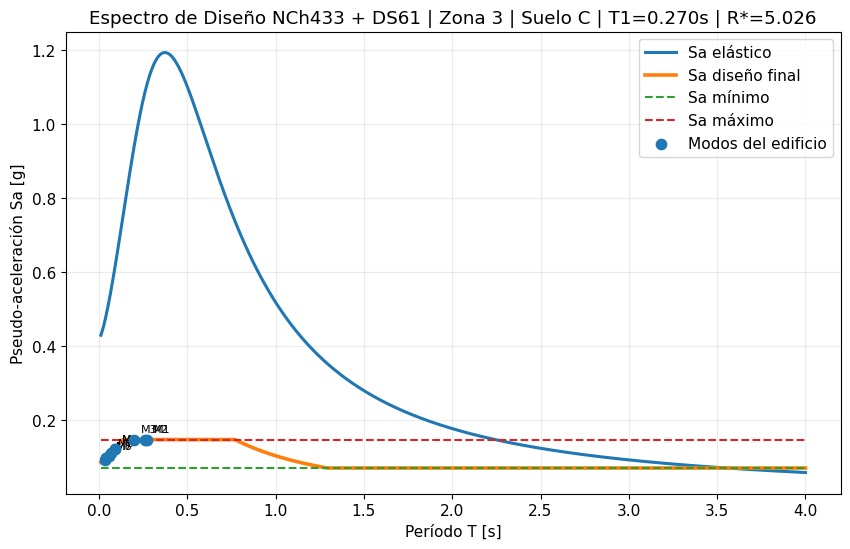

Figura guardada: C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\reports\figures\NB3_00_alpha_piloto.png


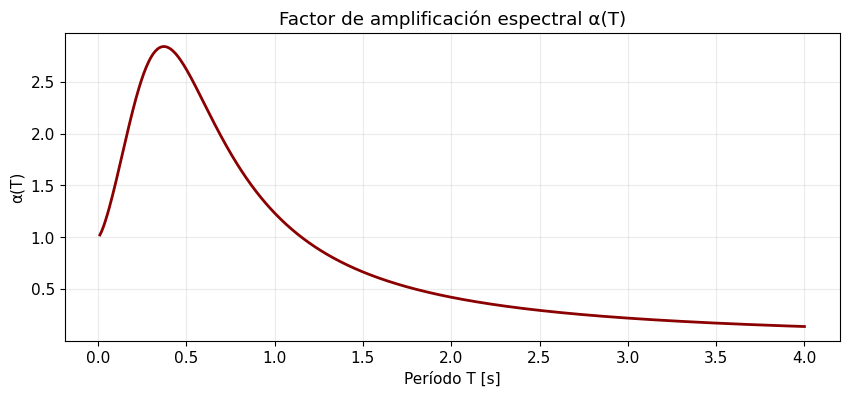

In [7]:
# ============================================================
# CELDA 7 — ESPECTRO DE DISEÑO DEFINITIVO (Excel Normativo)
# NCh433 Mod.Of2012 + DS61
# ============================================================

def plot_design_spectrum_case(params, modal=None, T_max=4.0, n_pts=900):
    """
    Grafica:
    - alpha(T)
    - Sa elástico
    - Sa diseño final
    - Sa mínimo
    - Sa máximo
    - Modos del edificio
    """

    T = np.linspace(0.01, T_max, n_pts)

    # período dominante del edificio
    if modal is not None:
        T_star = float(modal["T"][0])
    else:
        T_star = 0.30

    spec = Sa_design_excel(
        T,
        zone=params["zona"],
        soil=params["suelo"],
        I=I_FIXED,
        Ro=RO_FIXED,
        T_star=T_star
    )

    Sa_elastic = spec["Sa_elastic_g"]
    Sa_design  = spec["Sa_design_g"]
    Sa_min     = spec["Sa_min_g"]
    Sa_max     = spec["Sa_max_g"]
    alpha      = spec["alpha"]
    Rstar      = spec["Rstar"]

    # --------------------------------------------------------
    # FIGURA
    # --------------------------------------------------------
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(T, Sa_elastic, lw=2.2, label="Sa elástico")
    ax.plot(T, Sa_design, lw=2.6, label="Sa diseño final")
    ax.plot(T, Sa_min, "--", lw=1.5, label="Sa mínimo")
    ax.plot(T, Sa_max, "--", lw=1.5, label="Sa máximo")

    # --------------------------------------------------------
    # Modos del edificio
    # --------------------------------------------------------
    if modal is not None:
        Tr = np.asarray(modal["T"], dtype=float)

        spec_modes = Sa_design_excel(
            Tr,
            zone=params["zona"],
            soil=params["suelo"],
            I=I_FIXED,
            Ro=RO_FIXED,
            T_star=T_star
        )

        Sa_modes = spec_modes["Sa_design_g"]

        ax.scatter(
            Tr,
            Sa_modes,
            s=55,
            zorder=10,
            label="Modos del edificio"
        )

        for i, (tt, ss) in enumerate(zip(Tr[:8], Sa_modes[:8]), start=1):
            ax.annotate(
                f"M{i}",
                (tt, ss),
                textcoords="offset points",
                xytext=(5, 5),
                fontsize=8
            )

    # --------------------------------------------------------
    # FORMATO
    # --------------------------------------------------------
    ax.set_xlabel("Período T [s]")
    ax.set_ylabel("Pseudo-aceleración Sa [g]")

    ax.set_title(
        f"Espectro de Diseño NCh433 + DS61 | "
        f"Zona {params['zona']} | Suelo {params['suelo']} | "
        f"T1={T_star:.3f}s | R*={Rstar:.3f}"
    )

    ax.grid(alpha=0.25)
    ax.legend(loc="best")

    save_path = OUT_FIG_DIR / "NB3_00_espectro_piloto_definitivo.png"
    plt.savefig(save_path, dpi=180, bbox_inches="tight")

    print("Figura guardada:", save_path)
    plt.show()

    # --------------------------------------------------------
    # SUBGRÁFICO α(T)
    # --------------------------------------------------------
    fig2, ax2 = plt.subplots(figsize=(10,4))
    ax2.plot(T, alpha, color="darkred", lw=2.0)
    ax2.set_xlabel("Período T [s]")
    ax2.set_ylabel("α(T)")
    ax2.set_title("Factor de amplificación espectral α(T)")
    ax2.grid(alpha=0.25)

    save_path2 = OUT_FIG_DIR / "NB3_00_alpha_piloto.png"
    plt.savefig(save_path2, dpi=180, bbox_inches="tight")

    print("Figura guardada:", save_path2)
    plt.show()


# ============================================================
# IMPRESIÓN TÉCNICA
# ============================================================
T1 = float(case_piloto["modal"]["T"][0])

spec_info = Sa_design_excel(
    np.array([T1]),
    zone=params_piloto["zona"],
    soil=params_piloto["suelo"],
    I=I_FIXED,
    Ro=RO_FIXED,
    T_star=T1
)

print("="*100)
print("PARÁMETROS DEL ESPECTRO DEL CASO PILOTO")
print("="*100)
print(f"Zona sísmica : {params_piloto['zona']}")
print(f"Suelo        : {params_piloto['suelo']}")
print(f"T1 edificio  : {T1:.4f} s")
print(f"A0           : {spec_info['A0']:.3f} g")
print(f"S            : {spec_info['S']:.3f}")
print(f"T0           : {spec_info['T0']:.3f} s")
print(f"Tp           : {spec_info['Tp']:.3f} s")
print(f"n            : {spec_info['n']:.3f}")
print(f"I            : {I_FIXED:.2f}")
print(f"R0           : {RO_FIXED:.2f}")
print(f"R*           : {spec_info['Rstar']:.3f}")
print("="*100)

plot_design_spectrum_case(
    params_piloto,
    modal=case_piloto["modal"],
    T_max=4.0
)

## 🏭 Hito — Generación del PKL final (corazón del notebook)

Bucle de generación de los **10.000 casos** con muestreo uniforme sobre `N_pisos × suelo × zona`. Cada candidato se construye con `build_params_B(randomize=True)`, se le aplica la **modulación de 5 cm**, se analiza por completo y se somete a `structural_case_ok`, que lo acepta o lo rechaza registrando el **motivo** (n.º de muros, densidad alta/baja, $K_x/K_y$ fuera de rango, fallo geométrico o modal, $L_x$ excesivo, B3 inactivo, excepción). Los contadores por filtro dejan trazabilidad para documentar la tesis.

**Se obtiene:** las listas `cases` (objetos completos) y `rows` (filas tabulares) del dataset aceptado, más el desglose de cuántos casos rechazó cada filtro.

In [8]:
# ============================================================
# CELDA 8 — GENERACIÓN DATASET FINAL CON CONTADORES DE FILTROS
# Distribución uniforme: N_pisos × suelo × zona
# NUEVO: contadores por filtro para documentación de tesis
# ============================================================

cases = []
rows  = []

accepted = 0
rejected = 0
attempts = 0

MAX_ATTEMPTS = N_CASES_TOTAL * 50

# ── Contadores por filtro ─────────────────────────────────────────────────
filtros_conteo = {
    'n_walls'        : 0,
    'density_baja'   : 0,
    'density_alta'   : 0,
    'Kxy_bajo'       : 0,
    'Kxy_alto'       : 0,
    'geometry_fail'  : 0,
    'modal_fail'     : 0,
    'Lx_exceso'      : 0,
    'B3_inactivo'    : 0,
    'excepcion'      : 0,
}

# ------------------------------------------------------------
# FUNCIÓN DE CALIDAD ESTRUCTURAL — ahora devuelve motivo
# ------------------------------------------------------------
def structural_case_ok(row):
    if row["n_walls"] < MIN_WALLS:
        return False, 'n_walls'
    if row["wall_density_plan"] < WALL_DENSITY_MIN:
        return False, 'density_baja'
    if row["wall_density_plan"] > WALL_DENSITY_MAX:
        return False, 'density_alta'
    if row["Kx_Ky_ratio"] < K_RATIO_MIN:
        return False, 'Kxy_bajo'
    if row["Kx_Ky_ratio"] > K_RATIO_MAX:
        return False, 'Kxy_alto'
    if not row["geometry_pass"]:
        return False, 'geometry_fail'
    if not row["modal_pass"]:
        return False, 'modal_fail'
    if row.get("Lx_m", 0) > LX_MAX_M:
        return False, 'Lx_exceso'
    B2 = row.get("activar_B2", 1)
    B3 = row.get("activar_B3", 1)
    if B3 == 0:
        return False, 'B3_inactivo'
    if B2 == 1 and B3 == 0:
        return False, 'B3_inactivo'
    return True, None

# ------------------------------------------------------------
# FUNCIÓN DE REDONDEO APLICADA A PARAMS — sin cambios
# ------------------------------------------------------------
def aplicar_redondeo_5cm(params):
    params["L_mod_m"]          = round_5cm(params["L_mod_m"])
    params["prof_depto_m"]     = round_5cm(params["prof_depto_m"])
    params["ancho_corredor_m"] = round_5cm(params["ancho_corredor_m"])
    params["L_nucleo_m"]       = round_5cm(params["L_nucleo_m"])
    params["B_nucleo_m"]       = round_5cm(params["B_nucleo_m"])
    params["h_story_m"]        = round_5cm(params["h_story_m"])
    return params

# ------------------------------------------------------------
# MUESTREO ÚNICO — sin cambios
# ------------------------------------------------------------
def sample_case():
    N     = int(rng.choice(ALL_FLOORS))
    suelo = str(rng.choice(ALL_SOILS))
    zona  = int(rng.choice([1, 2, 3]))
    params = build_params_B(
        FAMILIA_B_CFG,
        randomize=True,
        seed=int(rng.integers(0, 10_000_000))
    )
    params["N_pisos"]    = N
    params["suelo"]      = suelo
    params["zona"]       = zona
    params["activar_B2"] = int(rng.choice([0, 1], p=[0.20, 0.80]))
    params["activar_B3"] = 1
    params = aplicar_redondeo_5cm(params)
    return params

# ------------------------------------------------------------
# VERIFICACIÓN PREVIA — sin cambios
# ------------------------------------------------------------
_rng_test = np.random.default_rng(9999)

def _sample_test():
    p = build_params_B(FAMILIA_B_CFG, randomize=True,
                       seed=int(_rng_test.integers(0, 10_000_000)))
    p["N_pisos"]    = int(_rng_test.choice(ALL_FLOORS))
    p["suelo"]      = str(_rng_test.choice(ALL_SOILS))
    p["zona"]       = int(_rng_test.choice([1, 2, 3]))
    p["activar_B2"] = int(_rng_test.choice([0, 1], p=[0.20, 0.80]))
    p["activar_B3"] = 1
    return aplicar_redondeo_5cm(p)

print("Verificación redondeo a 5cm — 1 caso de prueba:")
_p = _sample_test()
for c in ["L_mod_m","prof_depto_m","ancho_corredor_m",
          "L_nucleo_m","B_nucleo_m","h_story_m","Lx_m","Ly_m","H_total_m"]:
    v = _p[c]
    ok = "✅" if abs(round(v/0.05)*0.05 - v) < 1e-4 else "⚠️"
    print(f"  {c:<20}: {v:.4f} m  {ok}")

# ------------------------------------------------------------
# GENERACIÓN PRINCIPAL
# ------------------------------------------------------------
print("="*70)
print("GENERACIÓN DATASET FINAL — DOMINIO ÚNICO UNIFORME")
print("="*70)
print(f"N casos        : {N_CASES_TOTAL}")
print(f"N_pisos rango  : {ALL_FLOORS[0]} a {ALL_FLOORS[-1]}")
print(f"Suelos         : {ALL_SOILS}")
print(f"Zonas          : [1, 2, 3]")
print(f"B2             : 80% activo, 20% inactivo")
print(f"B3             : siempre activo")
print(f"Modulación     : 5cm en todos los parámetros geométricos")
print(f"Filtros        : wall_density, Kx/Ky, geometry, modal, B3≥1, Lx≤{LX_MAX_M:.0f}m")
print("="*70)

PRINT_EVERY = max(1, N_CASES_TOTAL // 20)

while accepted < N_CASES_TOTAL and attempts < MAX_ATTEMPTS:

    attempts += 1
    params = sample_case()

    try:
        geom = build_family_B_geometry(params)
        case = analyze_family_B_dataset_case(
            params=params,
            geom=geom,
            case_id=accepted,
            sample_seed=int(params.get("seed", attempts)),
            rigidity_class="uniform"
        )

        row = case["row"].copy()
        row["domain_tag"] = "uniform"
        row["attempt_id"] = attempts

        ok, motivo = structural_case_ok(row)
        if ok:
            rows.append(row)
            cases.append(case)
            accepted += 1
        else:
            rejected += 1
            filtros_conteo[motivo] += 1

    except Exception:
        rejected += 1
        filtros_conteo['excepcion'] += 1

    if accepted % PRINT_EVERY == 0 and accepted > 0 and attempts % 2 == 0:
        print(f"  {accepted:6d}/{N_CASES_TOTAL}  "
              f"aceptación={100*accepted/max(1,attempts):.1f}%  "
              f"rechazados={rejected}")

dataset_df = pd.DataFrame(rows)

# ------------------------------------------------------------
# RESUMEN FINAL
# ------------------------------------------------------------
print("="*70)
print("GENERACIÓN FINALIZADA")
print("="*70)
print(f"Intentos       : {attempts}")
print(f"Aceptados      : {accepted}")
print(f"Rechazados     : {rejected}")
print(f"Tasa aceptación: {100*accepted/max(1, attempts):.2f}%")

# ── Tabla de filtros ──────────────────────────────────────────────────────
print(f"\n{'='*55}")
print(f"CASOS RECHAZADOS POR FILTRO")
print(f"{'='*55}")
print(f"  {'Filtro':<22} {'Rechazados':>12} {'% del total':>12}")
print(f"  {'-'*48}")

descripciones = {
    'n_walls'      : 'Muros < 10',
    'density_baja' : 'Densidad < 2%',
    'density_alta' : 'Densidad > 9%',
    'Kxy_bajo'     : 'Kx/Ky < 0.35',
    'Kxy_alto'     : 'Kx/Ky > 3.00',
    'geometry_fail': 'Geometría inválida',
    'modal_fail'   : 'Modal no converge',
    'Lx_exceso'    : f'Lx > {LX_MAX_M:.0f}m',
    'B3_inactivo'  : 'B3 inactivo',
    'excepcion'    : 'Excepción Python',
}

for key, desc in descripciones.items():
    cnt = filtros_conteo[key]
    pct = 100 * cnt / max(1, rejected)
    print(f"  {desc:<22} {cnt:>12,} {pct:>11.1f}%")

print(f"  {'-'*48}")
print(f"  {'TOTAL RECHAZADOS':<22} {rejected:>12,} {'100.0':>11}%")
print(f"{'='*55}")

# ── Resto del resumen original ────────────────────────────────────────────
print("\nDistribución N_pisos × suelo:")
print(pd.crosstab(dataset_df["N_pisos"], dataset_df["suelo"]))
print("\nDistribución N_pisos × zona:")
print(pd.crosstab(dataset_df["N_pisos"], dataset_df["zona"]))
print("\nDistribución B2:")
print(dataset_df["activar_B2"].value_counts().sort_index()
      .rename({0:"B2=0 (sin fachada)", 1:"B2=1 (con fachada)"}))
print("\nVerificación B3=0:", (dataset_df["activar_B3"]==0).sum(), "casos → ",
      "✔ Ninguno" if (dataset_df["activar_B3"]==0).sum()==0 else "⚠ Revisar")

print("\nVerificación redondeo 5cm en dataset final:")
for col in ["L_mod_m","prof_depto_m","ancho_corredor_m",
            "L_nucleo_m","B_nucleo_m","h_story_m"]:
    if col in dataset_df.columns:
        mal = (np.abs(dataset_df[col]/0.05 -
               np.round(dataset_df[col]/0.05)) > 1e-4).sum()
        print(f"  {col:<20}: {mal} casos fuera de modulación  "
              f"{'✅' if mal==0 else '⚠️'}")

print("="*70)
display(dataset_df.head())

Verificación redondeo a 5cm — 1 caso de prueba:
  L_mod_m             : 3.3500 m  ✅
  prof_depto_m        : 7.4500 m  ✅
  ancho_corredor_m    : 1.7000 m  ✅
  L_nucleo_m          : 5.8500 m  ✅
  B_nucleo_m          : 4.8000 m  ✅
  h_story_m           : 2.9000 m  ✅
  Lx_m                : 99.0180 m  ⚠️
  Ly_m                : 16.6088 m  ⚠️
  H_total_m           : 37.7000 m  ✅
GENERACIÓN DATASET FINAL — DOMINIO ÚNICO UNIFORME
N casos        : 10000
N_pisos rango  : 6 a 18
Suelos         : ['A', 'B', 'C', 'D']
Zonas          : [1, 2, 3]
B2             : 80% activo, 20% inactivo
B3             : siempre activo
Modulación     : 5cm en todos los parámetros geométricos
Filtros        : wall_density, Kx/Ky, geometry, modal, B3≥1, Lx≤100m
    2000/10000  aceptación=84.9%  rechazados=356
    2000/10000  aceptación=84.8%  rechazados=358
    2500/10000  aceptación=85.0%  rechazados=442
    3000/10000  aceptación=84.9%  rechazados=532
    3000/10000  aceptación=84.9%  rechazados=534
    3500/10000  

,case_id,sample_seed,rigidity_class,N_pisos,suelo,zona,n_unid_lado,mods_por_depto,activar_B2,activar_B3,...,drift_max_x,drift_max_y,Vb_x_kN,Vb_y_kN,geometry_pass,modal_pass,cumple,motivo_falla,domain_tag,attempt_id
0,0,2,uniform,7,B,2,3,2,1,1,...,0.000048,0.000088,4022.915353,4026.928752,True,True,True,cumple,uniform,2
1,1,3,uniform,15,D,3,5,2,1,1,...,0.000196,0.000384,23850.403219,23865.878402,True,True,True,cumple,uniform,3
2,2,4,uniform,7,B,1,5,2,1,1,...,0.000032,0.000057,4923.258038,4927.873707,True,True,True,cumple,uniform,4
3,3,5,uniform,9,C,2,4,2,1,1,...,0.000074,0.000122,8814.943896,8822.595186,True,True,True,cumple,uniform,5
4,4,6,uniform,14,D,2,3,2,1,1,...,0.000111,0.000197,9519.790824,9525.020256,True,True,True,cumple,uniform,6


## 💾 Hito — Guardado de entregables finales

Persiste el **producto final** en `dataset/final/` con marca de tiempo: el **CSV** tabular (`dataset_familyB_final_*.csv`), el **PKL** con los casos completos (`dataset_familyB_cases_*.pkl`) y un **JSON de metadata** (n.º de casos, semilla, tasas de cumplimiento, estadísticos de $T_1$ y deriva, listado de columnas). Incluye un chequeo del número de segmentos B4 generados.

**Se obtiene:** los tres archivos oficiales del dataset (CSV + PKL + metadata) que alimentan las etapas posteriores del pipeline (modelo OpenSees y entrenamiento de la PINN).

In [9]:
# ============================================================
# CELDA 9 — GUARDADO DE ENTREGABLES FINAL
# ============================================================
import json
import pickle
from datetime import datetime

# ------------------------------------------------------------
# NOMBRES
# ------------------------------------------------------------
stamp     = datetime.now().strftime("%Y%m%d_%H%M")
csv_path  = OUT_DATA_DIR / f"dataset_familyB_final_{stamp}.csv"
pkl_path  = OUT_DATA_DIR / f"dataset_familyB_cases_{stamp}.pkl"
json_path = OUT_DATA_DIR / f"dataset_familyB_metadata_{stamp}.json"

# ------------------------------------------------------------
# GUARDAR CSV
# ------------------------------------------------------------
dataset_df.to_csv(csv_path, index=False)

# ------------------------------------------------------------
# GUARDAR CASES COMPLETOS
# ------------------------------------------------------------
with open(pkl_path, "wb") as f:
    pickle.dump(cases, f)

# ------------------------------------------------------------
# METADATA
# ------------------------------------------------------------
meta = {
    "dataset_name": "familyB_final",
    "created":      stamp,
    "n_cases":      int(len(dataset_df)),
    "seed":         int(SEED),
    "n_realistic":  int((dataset_df["domain_tag"] == "realistic").sum()),
    "n_extreme":    int((dataset_df["domain_tag"] == "extreme").sum()),
    "cumple_rate":  float(dataset_df["cumple"].mean()),
    "T1_median":    float(dataset_df["T1_s"].median()),
    "T1_p90":       float(dataset_df["T1_s"].quantile(0.90)),
    "drift_x_p95":  float(dataset_df["drift_max_x"].quantile(0.95)),
    "drift_y_p95":  float(dataset_df["drift_max_y"].quantile(0.95)),
    "KxKy_median":  float(dataset_df["Kx_Ky_ratio"].median()),
    "columns":      list(dataset_df.columns),
    "notes":        "Notebook 3 FINAL | Dataset tesis PINN + NCh433 | B4-INF dividido por hall"
}
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=4, ensure_ascii=False)

# ------------------------------------------------------------
# REPORTE
# ------------------------------------------------------------
print("="*70)
print("ENTREGABLES GUARDADOS")
print("="*70)
print(f"CSV  : {csv_path.name}")
print(f"PKL  : {pkl_path.name}")
print(f"JSON : {json_path.name}")
print("="*70)
print("RESUMEN")
print("="*70)
print(f"N casos       : {len(dataset_df)}")
print(f"Cumple rate   : {dataset_df['cumple'].mean():.3f}")
print(f"T1 mediana    : {dataset_df['T1_s'].median():.3f} s")
print(f"Kx/Ky mediana : {dataset_df['Kx_Ky_ratio'].median():.3f}")

# Verificar B4 en PKL generado
n_b4_ok = sum(1 for c in cases
              if len(c['wall_df'][c['wall_df']['group']=='B4']) == 4)
n_inf_L  = sum(1 for c in cases
               if 'B4-INF-L' in c['wall_df']['label'].values)
print(f"B4 con 4 seg  : {n_b4_ok}/{len(cases)} ✅")
print(f"B4-INF-L      : {n_inf_L}/{len(cases)} ✅")
print("="*70)

ENTREGABLES GUARDADOS
CSV  : dataset_familyB_final_20260523_0758.csv
PKL  : dataset_familyB_cases_20260523_0758.pkl
JSON : dataset_familyB_metadata_20260523_0758.json
RESUMEN
N casos       : 10000
Cumple rate   : 1.000
T1 mediana    : 0.318 s
Kx/Ky mediana : 1.837
B4 con 4 seg  : 10000/10000 ✅
B4-INF-L      : 10000/10000 ✅


In [10]:
# ============================================================
# VERIFICACION GAPS B3 — PKL 20260523_0113
# ============================================================
import pickle
from pathlib import Path

PKL_PATH = sorted(OUT_DATA_DIR.glob('dataset_familyB_cases_*.pkl'),
                  key=lambda p: p.stat().st_mtime)[-1]
with open(PKL_PATH, 'rb') as f:
    cases = pickle.load(f)

print(f'PKL: {PKL_PATH.name}')
print(f'Total casos: {len(cases)}')
print()

problemas = []
for i, c in enumerate(cases):
    p     = c['params']
    wdf   = c['wall_df']
    Lx    = p['Lx_m']
    t_ext = p['t_muro_borde_m']
    t_mid = p['t_muro_mid_m']
    b3    = wdf[wdf['group'] == 'B3']
    for _, w in b3.iterrows():
        cx      = float(w['cx'])
        ww      = float(w['w'])
        gap_izq = (cx - ww/2) - t_ext
        gap_der = (Lx - t_ext) - (cx + ww/2)
        if gap_der < 0.10 or gap_izq < 0.10:
            problemas.append({
                'caso'   : i,
                'label'  : w['label'],
                'gap_izq': round(gap_izq, 4),
                'gap_der': round(gap_der, 4),
                'Lx'     : round(Lx, 3),
            })

print(f'B3 con gap < 10cm al extremo: {len(problemas)} casos')
for p in problemas[:10]:
    print(f'  Caso {p["caso"]:5d}: {p["label"]:<12} '
          f'gap_izq={p["gap_izq"]:>7.4f}m  '
          f'gap_der={p["gap_der"]:>7.4f}m  Lx={p["Lx"]}m')

PKL: dataset_familyB_cases_20260523_0758.pkl
Total casos: 10000

B3 con gap < 10cm al extremo: 0 casos


In [11]:
# Calcular gap correcto — último B3 de cada lado a su extremo
gaps_correctos = []
for i, c in enumerate(cases):
    p     = c['params']
    wdf   = c['wall_df']
    Lx    = p['Lx_m']
    t_ext = p['t_muro_borde_m']
    t_mid = p['t_muro_mid_m']
    ancho_depto = p['L_mod_m'] * p['mods_por_depto']

    b3_top = wdf[wdf['label'].str.contains('B3-T')].sort_values('cx')
    if len(b3_top) > 0:
        # Último medianero derecho → gap al extremo derecho
        ult_der = b3_top.iloc[-1]
        gap_der = (Lx - t_ext) - (float(ult_der['cx']) + t_mid/2)
        # Primer medianero izquierdo → gap al extremo izquierdo
        prim_izq = b3_top.iloc[0]
        gap_izq = (float(prim_izq['cx']) - t_mid/2) - t_ext

        gaps_correctos.append({
            'caso'      : i,
            'gap_der'   : round(gap_der, 4),
            'gap_izq'   : round(gap_izq, 4),
            'ancho_depto': ancho_depto,
        })

import numpy as np
gaps_der_arr = np.array([g['gap_der'] for g in gaps_correctos])
gaps_izq_arr = np.array([g['gap_izq'] for g in gaps_correctos])

print('=== GAP ULTIMO MEDIANERO → EXTREMO DERECHO ===')
print(f'  Min  : {gaps_der_arr.min():.4f} m')
print(f'  Max  : {gaps_der_arr.max():.4f} m')
print(f'  Media: {gaps_der_arr.mean():.4f} m')
print(f'  P5   : {np.percentile(gaps_der_arr, 5):.4f} m')
print(f'  P50  : {np.percentile(gaps_der_arr, 50):.4f} m')
print(f'  P95  : {np.percentile(gaps_der_arr, 95):.4f} m')

# Cuantos quedan a más de 1.5 × ancho_depto del extremo
n_grandes = sum(1 for g in gaps_correctos 
                if g['gap_der'] > g['ancho_depto'] * 1.5)
print(f'\n  Gaps > 1.5×ancho_depto: {n_grandes}/{len(gaps_correctos)}')

print()
print('=== GAP PRIMER MEDIANERO → EXTREMO IZQUIERDO ===')
print(f'  Min  : {gaps_izq_arr.min():.4f} m')
print(f'  Max  : {gaps_izq_arr.max():.4f} m')
print(f'  Media: {gaps_izq_arr.mean():.4f} m')

=== GAP ULTIMO MEDIANERO → EXTREMO DERECHO ===
  Min  : 5.5342 m
  Max  : 7.8087 m
  Media: 6.6715 m
  P5   : 5.9788 m
  P50  : 6.6624 m
  P95  : 7.3625 m

  Gaps > 1.5×ancho_depto: 0/10000

=== GAP PRIMER MEDIANERO → EXTREMO IZQUIERDO ===
  Min  : 6.0250 m
  Max  : 7.3750 m
  Media: 6.6676 m


PKL: dataset_familyB_cases_20260523_0758.pkl — 10000 casos


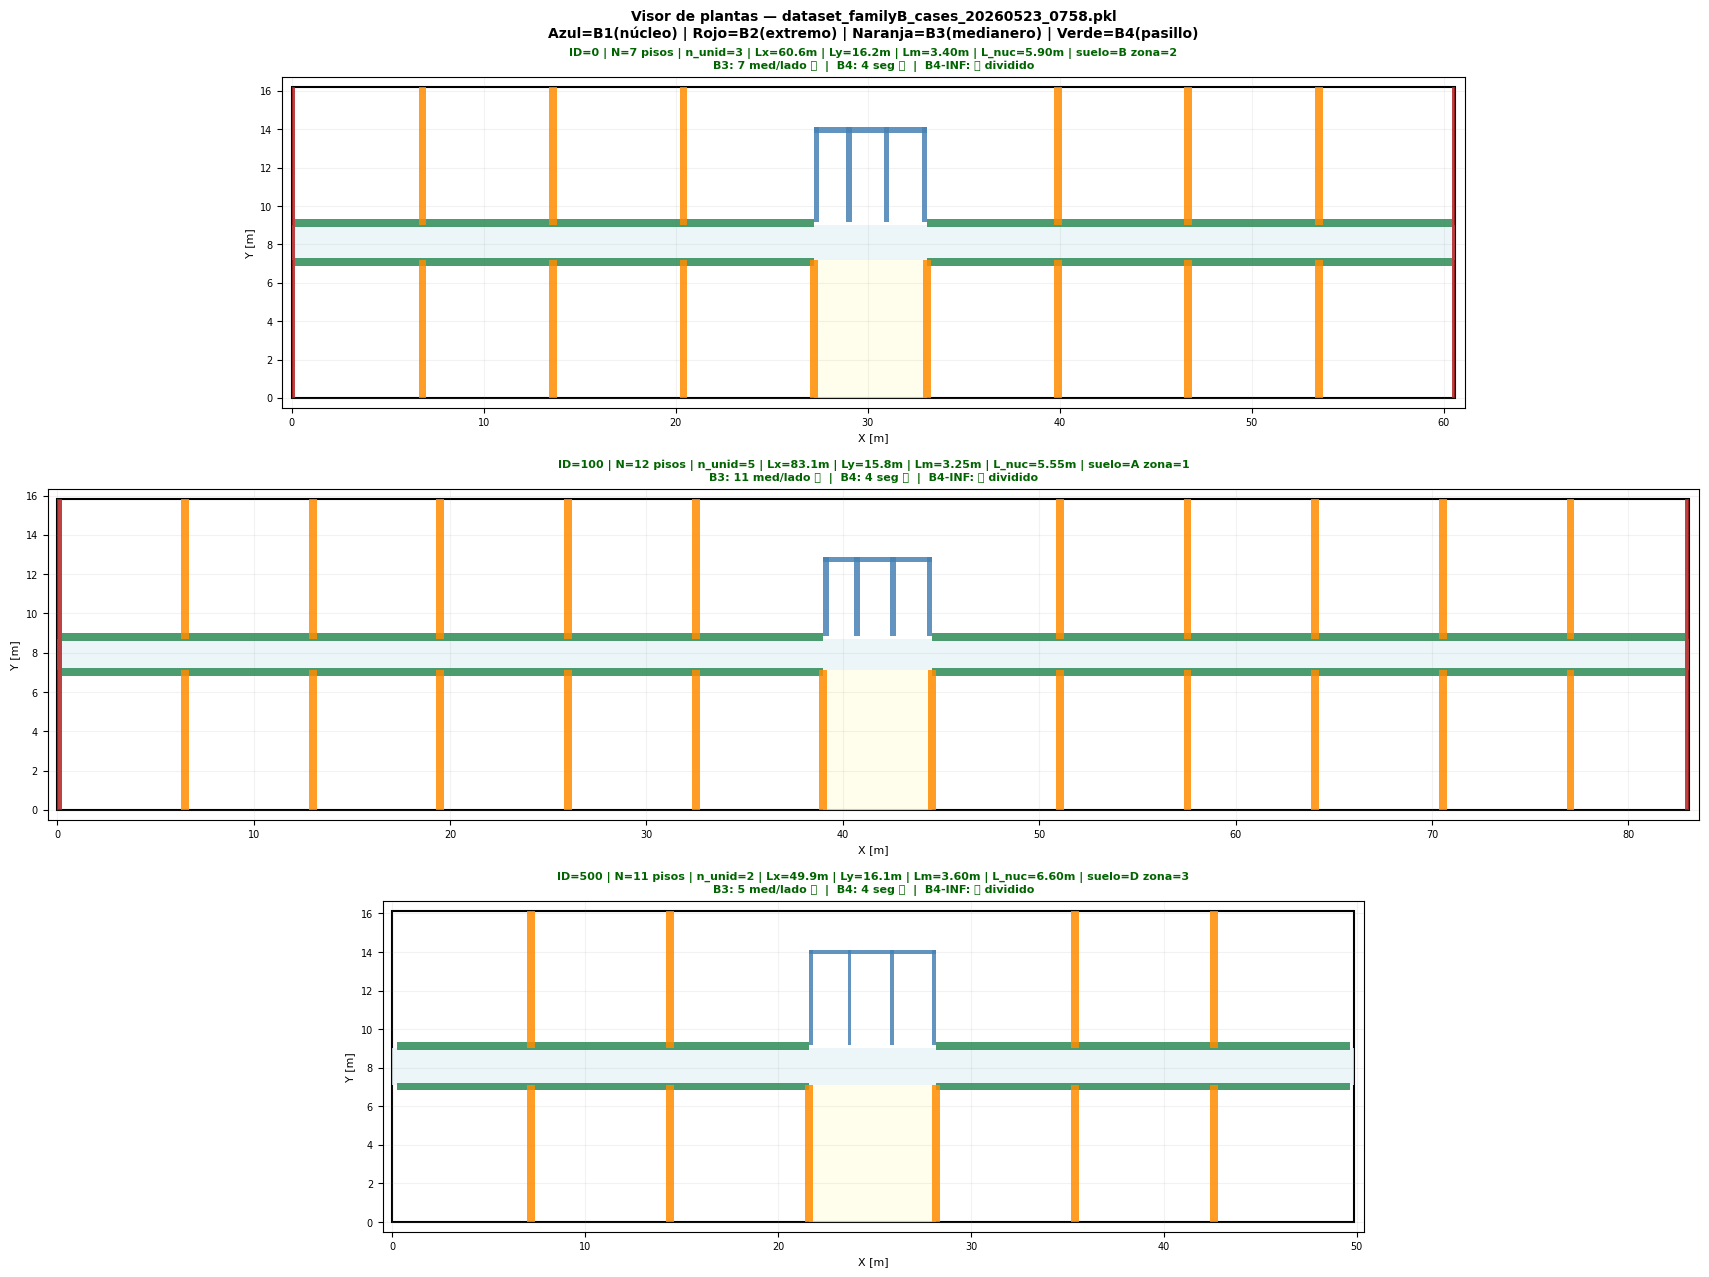

IDs mostrados: [0, 100, 500]
Cambia IDS_MOSTRAR y vuelve a correr


In [12]:
# ============================================================
# VISOR DE PLANTAS — 3 casos elegibles
# ============================================================
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

# ── CONFIGURA AQUÍ ────────────────────────────────────────────────────────
IDS_MOSTRAR = [0, 100, 500]
# ─────────────────────────────────────────────────────────────────────────

PKL_PATH = sorted(OUT_DATA_DIR.glob('dataset_familyB_cases_*.pkl'),
                  key=lambda p: p.stat().st_mtime)[-1]
with open(PKL_PATH, 'rb') as f:
    cases = pickle.load(f)
print(f'PKL: {PKL_PATH.name} — {len(cases)} casos')

color_map = {
    'B1': 'steelblue',
    'B2': 'firebrick',
    'B3': 'darkorange',
    'B4': 'seagreen',
}

# Espesor mínimo visual para muros delgados (B3, B4)
ESPESOR_MIN_VISUAL = 0.40  # m — solo para visualización

fig, axes = plt.subplots(3, 1, figsize=(20, 13))
fig.suptitle(
    f'Visor de plantas — {PKL_PATH.name}\n'
    f'Azul=B1(núcleo) | Rojo=B2(extremo) | Naranja=B3(medianero) | Verde=B4(pasillo)',
    fontsize=10, fontweight='bold'
)

for ax, idx in zip(axes, IDS_MOSTRAR):
    if idx >= len(cases):
        ax.text(0.5, 0.5, f'ID {idx} fuera de rango (max={len(cases)-1})',
                ha='center', va='center', transform=ax.transAxes, fontsize=12)
        continue

    c   = cases[idx]
    p   = c['params']
    wdf = c['wall_df']
    Lx  = p['Lx_m']
    Ly  = p['Ly_m']

    ax.set_facecolor('white')
    ax.set_xlim(-0.5, Lx + 0.5)
    ax.set_ylim(-0.5, Ly + 0.5)
    ax.set_aspect('equal')

    # Contorno
    ax.add_patch(patches.Rectangle(
        (0, 0), Lx, Ly,
        fill=False, edgecolor='black', lw=1.5, zorder=1))

    # Corredor
    y_cor_0 = p['prof_depto_inf_m']
    y_cor_1 = y_cor_0 + p['ancho_corredor_m']
    ax.add_patch(patches.Rectangle(
        (0, y_cor_0), Lx, p['ancho_corredor_m'],
        facecolor='#e8f4f8', edgecolor='none', alpha=0.8, zorder=1))

    # Hall
    x_nuc_0 = p['n_mod_izq'] * p['L_mod_m']
    x_nuc_1 = x_nuc_0 + p['L_nucleo_m']
    ax.add_patch(patches.Rectangle(
        (x_nuc_0, 0), p['L_nucleo_m'], y_cor_0,
        facecolor='#fffde7', edgecolor='none', alpha=0.8, zorder=1))

    # Muros
    for _, w in wdf.iterrows():
        cx    = float(w['cx'])
        cy    = float(w['cy'])
        ww    = float(w['w'])
        hw    = float(w['h'])
        grp   = w['group']
        color = color_map.get(grp, 'gray')

        # Amplificar espesor mínimo visual
        # B3 (vertical): amplificar ancho (ww es delgado)
        # B4 (horizontal): amplificar alto (hw es delgado)
        if grp == 'B3':
            ww_plot = max(ww, ESPESOR_MIN_VISUAL)
            hw_plot = hw
        elif grp == 'B4':
            ww_plot = ww
            hw_plot = max(hw, ESPESOR_MIN_VISUAL)
        else:
            ww_plot = ww
            hw_plot = hw

        ax.add_patch(patches.Rectangle(
            (cx - ww_plot/2, cy - hw_plot/2), ww_plot, hw_plot,
            facecolor=color, edgecolor='none',
            alpha=0.85, zorder=3))

    # Info
    b3    = wdf[wdf['group'] == 'B3']
    b4    = wdf[wdf['group'] == 'B4']
    t_ext = p['t_muro_borde_m']
    b4_ok = len(b4) == 4
    gap_ok = all(
        float(w['cx']) - float(w['w'])/2 > t_ext + 0.05 and
        float(w['cx']) + float(w['w'])/2 < Lx - t_ext - 0.05
        for _, w in b3.iterrows()
    )

    ax.set_title(
        f"ID={idx} | N={p['N_pisos']} pisos | n_unid={p['n_unid_lado']} | "
        f"Lx={Lx:.1f}m | Ly={Ly:.1f}m | Lm={p['L_mod_m']:.2f}m | "
        f"L_nuc={p['L_nucleo_m']:.2f}m | suelo={p['suelo']} zona={p['zona']}\n"
        f"B3: {len(b3)//2} med/lado {'✅' if gap_ok else '❌'}  |  "
        f"B4: {len(b4)} seg {'✅' if b4_ok else '❌'}  |  "
        f"B4-INF: {'✅ dividido' if any('INF-L' in l for l in b4['label'].tolist()) else '❌'}",
        fontsize=8, fontweight='bold',
        color='darkgreen' if (gap_ok and b4_ok) else 'red'
    )
    ax.set_xlabel('X [m]', fontsize=8)
    ax.set_ylabel('Y [m]', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.grid(alpha=0.10, color='gray')

plt.tight_layout()
plt.savefig(OUT_DATA_DIR / f'visor_{IDS_MOSTRAR[0]}_{IDS_MOSTRAR[1]}_{IDS_MOSTRAR[2]}.png',
            dpi=130, bbox_inches='tight')
plt.show()
print(f'IDs mostrados: {IDS_MOSTRAR}')
print('Cambia IDS_MOSTRAR y vuelve a correr')

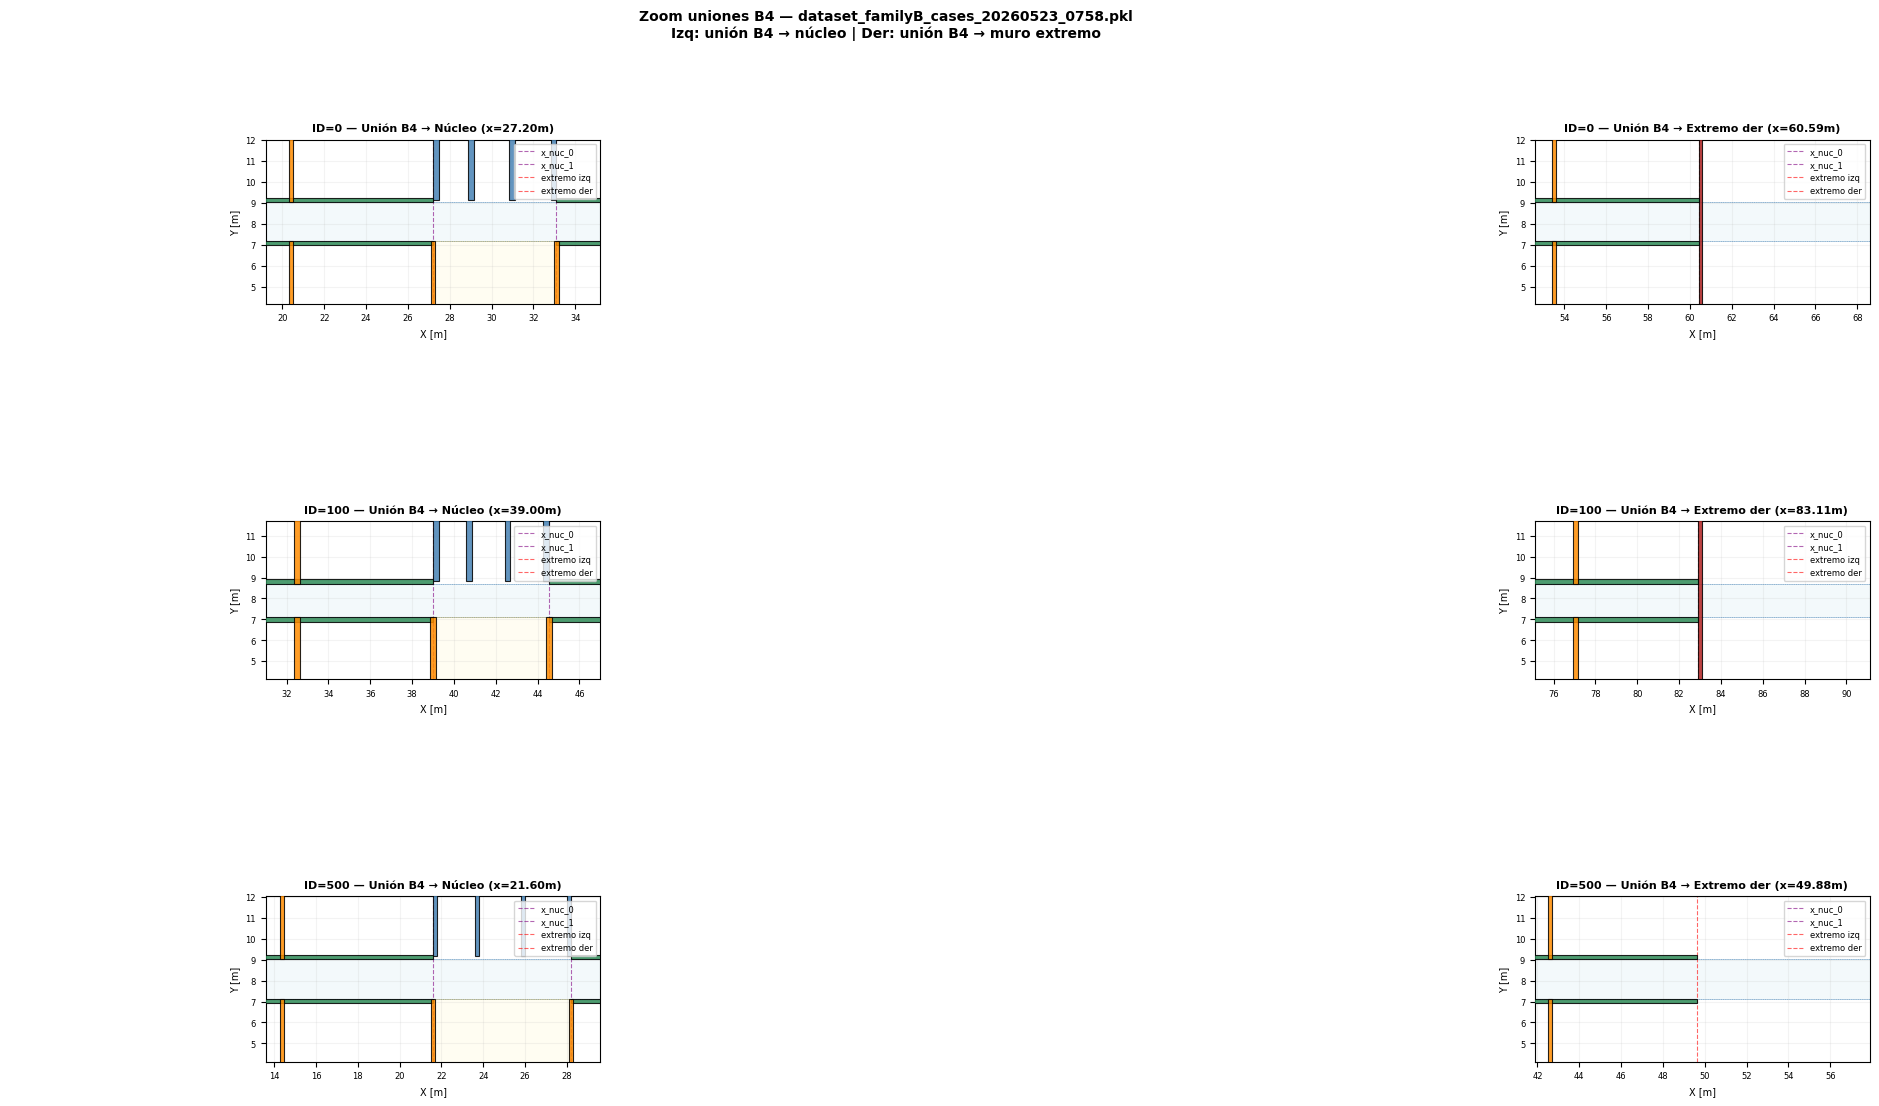

Zoom guardado — IDs: [0, 100, 500]


In [13]:
# ============================================================
# ZOOM UNIONES B4 — NUCLEO Y EXTREMOS
# Toma los mismos IDS_MOSTRAR de la celda anterior
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.patches as patches

ZOOM_M = 8.0  # metros de margen para el zoom

fig, axes = plt.subplots(len(IDS_MOSTRAR), 2, 
                          figsize=(20, len(IDS_MOSTRAR) * 4))
fig.suptitle(
    f'Zoom uniones B4 — {PKL_PATH.name}\n'
    f'Izq: unión B4 → núcleo | Der: unión B4 → muro extremo',
    fontsize=10, fontweight='bold'
)

for row, idx in enumerate(IDS_MOSTRAR):
    c   = cases[idx]
    p   = c['params']
    wdf = c['wall_df']
    Lx  = p['Lx_m']
    Ly  = p['Ly_m']
    t_ext   = p['t_muro_borde_m']
    y_cor_0 = p['prof_depto_inf_m']
    y_cor_1 = y_cor_0 + p['ancho_corredor_m']
    x_nuc_0 = p['n_mod_izq'] * p['L_mod_m']
    x_nuc_1 = x_nuc_0 + p['L_nucleo_m']

    for col, (x_centro, titulo) in enumerate([
        (x_nuc_0, f'ID={idx} — Unión B4 → Núcleo (x={x_nuc_0:.2f}m)'),
        (Lx,      f'ID={idx} — Unión B4 → Extremo der (x={Lx:.2f}m)'),
    ]):
        ax = axes[row][col]
        ax.set_facecolor('white')

        # Zoom area
        x_min = x_centro - ZOOM_M
        x_max = x_centro + ZOOM_M
        y_min = y_cor_0 - 3.0
        y_max = y_cor_1 + 3.0

        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_aspect('equal')

        # Corredor
        ax.add_patch(patches.Rectangle(
            (x_min, y_cor_0), x_max - x_min, p['ancho_corredor_m'],
            facecolor='#e8f4f8', edgecolor='steelblue',
            lw=0.5, alpha=0.5, zorder=1))

        # Hall
        ax.add_patch(patches.Rectangle(
            (x_nuc_0, 0), p['L_nucleo_m'], y_cor_0,
            facecolor='#fffde7', edgecolor='goldenrod',
            lw=0.5, alpha=0.5, zorder=1))

        # Líneas de referencia
        ax.axvline(x_nuc_0, color='purple', ls='--', lw=0.8, alpha=0.6, label='x_nuc_0')
        ax.axvline(x_nuc_1, color='purple', ls='--', lw=0.8, alpha=0.6, label='x_nuc_1')
        ax.axvline(t_ext,   color='red',    ls='--', lw=0.8, alpha=0.6, label='extremo izq')
        ax.axvline(Lx-t_ext,color='red',   ls='--', lw=0.8, alpha=0.6, label='extremo der')
        ax.axhline(y_cor_0, color='steelblue', ls=':', lw=0.6, alpha=0.5)
        ax.axhline(y_cor_1, color='steelblue', ls=':', lw=0.6, alpha=0.5)

        # Muros — con borde para ver límites exactos
        for _, w in wdf.iterrows():
            cx    = float(w['cx'])
            cy    = float(w['cy'])
            ww    = float(w['w'])
            hw    = float(w['h'])
            grp   = w['group']
            color = color_map.get(grp, 'gray')

            # Solo muros dentro del zoom
            x0 = cx - ww/2; x1 = cx + ww/2
            y0 = cy - hw/2; y1 = cy + hw/2
            if x1 < x_min or x0 > x_max:
                continue
            if y1 < y_min or y0 > y_max:
                continue

            ax.add_patch(patches.Rectangle(
                (x0, y0), ww, hw,
                facecolor=color, edgecolor='black',
                lw=0.8, alpha=0.85, zorder=3))

            # Anotar dimensión del muro en el zoom
            if grp == 'B4':
                ax.text(cx, cy, f'{ww:.2f}m',
                        ha='center', va='center',
                        fontsize=6, color='white',
                        fontweight='bold', zorder=5)

        ax.set_title(titulo, fontsize=8, fontweight='bold')
        ax.set_xlabel('X [m]', fontsize=7)
        ax.set_ylabel('Y [m]', fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(alpha=0.15)
        ax.legend(fontsize=6, loc='upper right')

plt.tight_layout()
plt.savefig(OUT_DATA_DIR / f'zoom_uniones_{IDS_MOSTRAR[0]}_{IDS_MOSTRAR[1]}_{IDS_MOSTRAR[2]}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Zoom guardado — IDs: {IDS_MOSTRAR}')

In [14]:
import pickle
from pathlib import Path

PKL_PATH = sorted(OUT_DATA_DIR.glob('dataset_familyB_cases_*.pkl'),
                  key=lambda p: p.stat().st_mtime)[-1]

with open(PKL_PATH, 'rb') as f:
    cases = pickle.load(f)

print(f'PKL: {PKL_PATH.name}')
print(f'Total casos: {len(cases)}')

# B4
n_b4_4seg  = sum(1 for c in cases if len(c['wall_df'][c['wall_df']['group']=='B4']) == 4)
n_inf_L    = sum(1 for c in cases if 'B4-INF-L' in c['wall_df']['label'].values)
n_sup_gap  = sum(1 for c in cases
                 if any('SUP' in l for l in c['wall_df'][c['wall_df']['group']=='B4']['label'].tolist()))

# B3 gaps
problemas = []
for i, c in enumerate(cases):
    p=c['params']; wdf=c['wall_df']
    Lx=p['Lx_m']; t_ext=p['t_muro_borde_m']; t_mid=p['t_muro_mid_m']
    b3=wdf[wdf['group']=='B3']
    for _,w in b3.iterrows():
        cx=float(w['cx']); ww=float(w['w'])
        if (cx-ww/2)-t_ext < 0.10 or (Lx-t_ext)-(cx+ww/2) < 0.10:
            problemas.append(i)

print(f'B4 con 4 segmentos : {n_b4_4seg}/{len(cases)}')
print(f'B4-INF-L presente  : {n_inf_L}/{len(cases)}')
print(f'B4-SUP presente    : {n_sup_gap}/{len(cases)}')
print(f'B3 gap < 10cm      : {len(problemas)} casos')
print()
if n_b4_4seg == len(cases) and n_inf_L == len(cases) and len(problemas) == 0:
    print('✅ PKL VERIFICADO — listo para NB3.2')
else:
    print('❌ PKL tiene problemas — revisar')

PKL: dataset_familyB_cases_20260523_0758.pkl
Total casos: 10000
B4 con 4 segmentos : 10000/10000
B4-INF-L presente  : 10000/10000
B4-SUP presente    : 10000/10000
B3 gap < 10cm      : 0 casos

✅ PKL VERIFICADO — listo para NB3.2


In [16]:
import pickle
from pathlib import Path

# PKL anterior que funcionó
PKL_OLD = Path(r'C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\final\dataset_familyB_cases_20260505_0005.pkl')
# PKL actual
PKL_NEW = sorted(Path(r'C:\Users\rodri\Documents\PINN\b2_proyecto\dataset\final').glob('dataset_familyB_cases_*.pkl'),
                 key=lambda p: p.stat().st_mtime)[-1]

with open(PKL_OLD, 'rb') as f:
    cases_old = pickle.load(f)
with open(PKL_NEW, 'rb') as f:
    cases_new = pickle.load(f)

# Comparar B4 caso 0 en ambos
for label, cases in [('VIEJO', cases_old), ('NUEVO', cases_new)]:
    c   = cases[0]
    p   = c['params']
    wdf = c['wall_df']
    y_cor_0 = p['prof_depto_inf_m']
    y_cor_1 = y_cor_0 + p['ancho_corredor_m']
    y_nuc_0 = y_cor_1 + p['gap_core_to_corridor_m']

    print(f'\n=== {label} — caso 0 ===')
    print(f'  y_cor_0={y_cor_0:.4f}  y_cor_1={y_cor_1:.4f}  y_nuc_0={y_nuc_0:.4f}')
    b4 = wdf[wdf['group']=='B4']
    for _, w in b4.iterrows():
        cy=float(w['cy']); hw=float(w['h'])
        print(f'  {w["label"]:<15} cy={cy:.4f} h={hw:.4f} '
              f'y_ini={cy-hw/2:.4f} y_fin={cy+hw/2:.4f}')


=== VIEJO — caso 0 ===
  y_cor_0=7.1791  y_cor_1=9.0291  y_nuc_0=9.1524
  B4-SUP-L        cy=9.1291 h=0.2000 y_ini=9.0291 y_fin=9.2291
  B4-SUP-R        cy=9.1291 h=0.2000 y_ini=9.0291 y_fin=9.2291
  B4-INF          cy=7.0791 h=0.2000 y_ini=6.9791 y_fin=7.1791

=== NUEVO — caso 0 ===
  y_cor_0=7.1791  y_cor_1=9.0291  y_nuc_0=9.1524
  B4-SUP-L        cy=9.1291 h=0.2000 y_ini=9.0291 y_fin=9.2291
  B4-SUP-R        cy=9.1291 h=0.2000 y_ini=9.0291 y_fin=9.2291
  B4-INF-L        cy=7.0791 h=0.2000 y_ini=6.9791 y_fin=7.1791
  B4-INF-R        cy=7.0791 h=0.2000 y_ini=6.9791 y_fin=7.1791


# Generación del archivo PKL de casos geométricos

En este notebook se genera el archivo `.pkl`, el cual constituye el insumo geométrico principal para las etapas posteriores del proyecto.  

Es importante destacar que este archivo **NO corresponde al dataset final de entrenamiento**, sino que almacena únicamente las **muestras geométricas y paramétricas** de los edificios que posteriormente serán procesadas mediante OpenSeesPy.

Cada muestra contiene la definición del edificio tipo, incluyendo variables como:

- Número de pisos
- Dimensiones en planta
- Alturas de entrepiso
- Configuración de muros
- Espesores
- Propiedades mecánicas
- Parámetros normativos
- Variables necesarias para construir el modelo FEM

El objetivo principal del `.pkl` es funcionar como una **base estructurada de casos sintéticos**, permitiendo separar claramente:

1. **La generación geométrica y paramétrica**  
2. **El análisis estructural en OpenSeesPy**

Posteriormente, OpenSees utiliza estas muestras para:

- Construir automáticamente los modelos FEM
- Ejecutar el análisis modal espectral
- Obtener períodos, modos y respuestas dinámicas
- Generar finalmente el dataset físico utilizado por la PINN

Por tanto, el `.pkl` debe entenderse como una **biblioteca de configuraciones estructurales**, y no como el dataset final de entrenamiento.